# Projeto: Modelo Preditivo de Evolução de Casos de Dengue

**Autor:** Celso Daniel

**Disciplina:** Data Science

## Objetivos
Este projeto utiliza modelos de Árvore de Decisão para prever se pacientes notificados com dengue serão hospitalizados, focando especialmente em comorbidades e sintomas clínicos. O objetivo é criar um modelo de triagem que possa ser utilizado no momento da entrada do paciente no sistema de saúde.

# Preparação dos Dados

## Importando bibliotecas

- **pandas** → manipulação e análise de dados em DataFrames.  
- **numpy** → cálculos numéricos com vetores e matrizes.  
- **seaborn** → visualizações estatísticas com boa estética.  
- **matplotlib.pyplot** → criação de gráficos personalizados.  
- **sklearn** → conjunto de ferramentas para Machine Learning, incluindo algoritmos de classificação, regressão, clustering, redução de dimensionalidade e pré-processamento de dados.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import chi2, f_classif

In [34]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Carregando os dados para um DataFrame

In [35]:
# df = pd.read_csv("dados/DENGBR21_25.csv", sep=";", low_memory=False)
df = pd.read_csv("dados/DENGBR21_25_BALANCEADO.csv", low_memory=False)

In [36]:
print(f"Total de linhas: {len(df)}")
print(f"Total de colunas: {len(df.columns)}")

Total de linhas: 971458
Total de colunas: 121


## Limpeza de Colunas Irrelevantes ou Incompletas

Antes da etapa de modelagem, foi realizada uma análise rigorosa de dados ausentes (*missing values*) tanto a nível de colunas (atributos) quanto de linhas (registros). O objetivo foi eliminar o ruído estatístico decorrente do preenchimento negligenciado ou condicional nas fichas do SINAN.

### Critérios de Exclusão de Atributos
Uma triagem automatizada foi aplicada para remover variáveis que se enquadrassem em pelo menos um dos três critérios abaixo:
1. **Atributos com mais de 60% de missing values:** Variáveis cujo preenchimento é extremamente esparso (como datas de exames específicos ou complicações raras) foram descartadas, pois a imputação de dados geraria vieses bizarros.
2. **Atributos de Variância Zero (Constantes):** Colunas que possuíam apenas um valor único para todas as linhas (ex: `TP_NOT` ou `ID_AGRAVO`, que identificam que todos os registros são notificações de dengue) não trazem poder preditivo e foram removidas.
3. **Vazamento de Informação (Data Leakage) e Metadados do Sistema:** Identificadores únicos, códigos de unidade de saúde, datas de digitação/encerramento e variáveis que revelavam o desfecho tardio do paciente (como `EVOLUCAO`, `CLASSI_FIN` e `DT_INTERNA`) foram removidos manualmente para evitar que o modelo fizesse predições baseadas em informações do futuro.

No total, **78 colunas** foram eliminadas do dataset original.

### Impacto da Limpeza na Qualidade da Base
A eficácia desta estratégia de filtragem é evidenciada pela drástica mudança no comportamento estatístico das linhas do dataset, conforme detalhado na tabela abaixo:

| Métrica de Missing por Linha | Base Bruta (Original) | Base Tratada (Pós-Limpeza) |
| :--- | :---: | :---: |
| **Média de Missing por Linha** | 50,16% | 7,91% |
| **Desvio Padrão (std)** | 7,68% | 7,77% |
| **Primeiro Quartil (25%)** | 48,76% | 2,27% |
| **Mediana (50%)** | 51,23% | 6,81% |
| **Terceiro Quartil (75%)** | 53,71% | 13,63% |
| **Máximo de Missing em uma Linha** | 76,03% | 60,46% |

### Análise dos Atributos Remanescentes
Após a filtragem, a base final estabilizou-se em **43 colunas**. Os dados ausentes residuais concentram-se majoritariamente em exames laboratoriais (como `HISTOPA_N` e `IMUNOH_N`, na faixa de 49% de missing). Esse comportamento é epidemiologicamente justificável, visto que nem todo paciente notificado realiza a confirmação via histopatologia ou isolamento viral.

Por outro lado, as variáveis de sintomas clínicos essenciais (como `FEBRE`, `CEFALEIA`, `VOMITO`, `DIABETES`, etc.) apresentaram uma taxa mínima de missing de apenas **1,05%**, garantindo uma matriz rica em sinais clínicos para que a Árvore de Decisão consiga mapear com segurança os padrões de evolução para hospitalização.

In [37]:
def show_missing_stats(df):
  missing_by_row = df.isna().mean(axis=1) * 100
  print("---------- Missing por Linhas ----------")
  print(missing_by_row.describe())
  print("----------------------------------------\n")

  missing_by_col = (df.isna().sum() / df.shape[0]).sort_values(ascending=False)
  print("---------- Missing por Colunas ---------")
  print(missing_by_col)
  print("----------------------------------------\n")

In [38]:
show_missing_stats(df)

---------- Missing por Linhas ----------
count    971458.000000
mean         50.161966
std           7.683479
min           3.305785
25%          48.760331
50%          51.239669
75%          53.719008
max          76.033058
dtype: float64
----------------------------------------

---------- Missing por Colunas ---------
DT_CHIK_S2    0.999989
DT_PRNT       0.999865
DT_CHIK_S1    0.999166
DT_VIRAL      0.995449
DT_OBITO      0.987007
SANGRAM       0.986240
HEMATURA      0.986240
DOENCA_TRA    0.986240
METRO         0.986240
GENGIVO       0.986240
MANI_HEMOR    0.986240
EPISTAXE      0.986240
LACO_N        0.986240
MIGRADO_W     0.986240
FLXRECEBI     0.986240
COMPLICA      0.986240
CON_FHD       0.986240
PLAQ_MENOR    0.986240
EVIDENCIA     0.986240
PLASMATICO    0.986240
PETEQUIAS     0.986240
DT_GRAV       0.986088
NDUPLIC_N     0.984387
RES_CHIKS2    0.984020
RESUL_PRNT    0.983991
CLINC_CHIK    0.982950
GRAV_MIOC     0.972372
GRAV_ORGAO    0.972372
GRAV_AST      0.972371
GRAV_SANG 

In [39]:
cols_to_remove = ["ID_REGIONA", "ID_UNIDADE", "ID_RG_RESI", "ID_PAIS"
                  , "TP_SISTEMA", "DT_DIGITA", "CS_FLXRET", "TPAUTOCTO",
                   "COUFINF", "COPAISINF", "SEM_NOT", "SEM_PRI", "ANO_NASC", "DT_ENCERRA", "EVOLUCAO", "CLASSI_FIN"]

for col in df.columns:
  if len(df[col].value_counts(dropna=False)) == 1 or df[col].isna().sum() / df.shape[0] > 0.60:
    cols_to_remove.append(col)

print("Colunas que serão removidas:", len(cols_to_remove))
print(cols_to_remove, "\n")

df = df.drop(columns=cols_to_remove)

Colunas que serão removidas: 78
['ID_REGIONA', 'ID_UNIDADE', 'ID_RG_RESI', 'ID_PAIS', 'TP_SISTEMA', 'DT_DIGITA', 'CS_FLXRET', 'TPAUTOCTO', 'COUFINF', 'COPAISINF', 'SEM_NOT', 'SEM_PRI', 'ANO_NASC', 'DT_ENCERRA', 'EVOLUCAO', 'CLASSI_FIN', 'TP_NOT', 'ID_AGRAVO', 'ID_OCUPA_N', 'DT_CHIK_S1', 'DT_CHIK_S2', 'DT_PRNT', 'RES_CHIKS1', 'RES_CHIKS2', 'RESUL_PRNT', 'DT_SORO', 'DT_NS1', 'DT_VIRAL', 'DT_PCR', 'SOROTIPO', 'DT_INTERNA', 'UF', 'MUNICIPIO', 'DOENCA_TRA', 'CLINC_CHIK', 'DT_OBITO', 'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT', 'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 'DT_ALRM', 'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO', 'DT_GRAV', 'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS', 'HEMATURA', 'SANGRAM', 'LACO_N', 'PLASMATICO', 'EVIDENCIA', 'PLAQ_MENOR', 'CON_FHD', 'COMPLICA', 'NDUPLIC_N', 'F

In [40]:
show_missing_stats(df)

---------- Missing por Linhas ----------
count    971458.000000
mean          8.097314
std           7.950348
min           0.000000
25%           2.325581
50%           6.976744
75%          13.953488
max          60.465116
dtype: float64
----------------------------------------

---------- Missing por Colunas ---------
HISTOPA_N     0.496823
IMUNOH_N      0.495801
RESUL_VI_N    0.443245
RESUL_SORO    0.436631
RESUL_PCR_    0.416359
RESUL_NS1     0.398053
COMUNINF      0.376302
CS_ESCOL_N    0.160316
CRITERIO      0.036260
FEBRE         0.010562
MIALGIA       0.010562
AUTO_IMUNE    0.010562
ACIDO_PEPT    0.010562
DOR_RETRO     0.010562
LACO          0.010562
ARTRALGIA     0.010562
ARTRITE       0.010562
LEUCOPENIA    0.010562
PETEQUIA_N    0.010562
HEMATOLOG     0.010562
HEPATOPAT     0.010562
EXANTEMA      0.010562
CEFALEIA      0.010562
VOMITO        0.010562
NAUSEA        0.010562
CONJUNTVIT    0.010562
DOR_COSTAS    0.010562
DIABETES      0.010562
RENAL         0.010562
HIPERTENSA

## Cálculo de Intervalos Temporais (Deltas)

Modelos baseados em árvores de decisão não conseguem extrair padrões diretos a partir de variáveis do tipo data/timestamp (como `DT_NOTIFIC`). Para extrair o valor preditivo oculto nesses metadados, transformou-se as datas brutas em variáveis numéricas contínuas de intervalos de tempo (Deltas), mapeando o comportamento do fluxo de atendimento.

### Criação de Novas Variáveis Preditivas

1. **`DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO`:** Calcula o tempo (em dias) que o paciente levou desde o aparecimento dos primeiros sintomas (`DT_SIN_PRI`) até o momento em que o caso foi formalmente notificado no sistema (`DT_NOTIFIC`). 
   * *Justificativa Clínica:* Pacientes que demoram mais a procurar o sistema de saúde ou cujos sintomas demoram a ser correlacionados com dengue podem apresentar maior risco de evolução grave e complicação por falta de manejo clínico oportuno. A distribuição mostrou que a grande maioria das notificações ocorre em até 4 dias após o início dos sintomas.

2. **`DELTA_NOTIFICACAO_INVESTIGACAO` (Temporária):** Calcula o tempo entre a notificação e o início da investigação epidemiológica (`DT_INVEST`). A análise exploratória revelou que em **93,7% dos casos** (`910.975` registros), a investigação inicia no exato mesmo dia ($0$ dias). Por apresentar variância quase nula no cenário global, essa métrica foi utilizada como diagnóstico operacional e descartada para a modelagem.

Após a extração dos deltas preditivos, realizou-se uma limpeza cirúrgica de segurança, eliminando as seguintes colunas remanescentes:
* **`DT_INVEST`, `DT_NOTIFIC` e `DT_SIN_PRI`:** Removidas por se tornarem redundantes após a engenharia de atributos.


In [41]:
df["DT_NOTIFIC"] = pd.to_datetime(df["DT_NOTIFIC"])
df["DT_SIN_PRI"] = pd.to_datetime(df["DT_SIN_PRI"])
df["DT_INVEST"] = pd.to_datetime(df["DT_INVEST"])

df["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO"] = (df["DT_NOTIFIC"] - df["DT_SIN_PRI"]).dt.days
print("------------------------------------------------------------")
print(df["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO"].value_counts().head())
print("------------------------------------------------------------\n")

df["DELTA_NOTIFICACAO_INVESTIGACAO"] = df["DT_INVEST"] - df["DT_NOTIFIC"]
print("------------------------------------------------------------")
print(df["DELTA_NOTIFICACAO_INVESTIGACAO"].value_counts().head())
print("------------------------------------------------------------\n")

df = df.drop(columns=["DELTA_NOTIFICACAO_INVESTIGACAO", "DT_INVEST", "DT_NOTIFIC", "DT_SIN_PRI"])

------------------------------------------------------------
DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO
1    155314
2    148873
3    142555
4    108184
0     84909
Name: count, dtype: int64
------------------------------------------------------------

------------------------------------------------------------
DELTA_NOTIFICACAO_INVESTIGACAO
0 days    910975
1 days     12594
2 days      5791
3 days      4554
4 days      3165
Name: count, dtype: int64
------------------------------------------------------------



## Limpeza Geográfica

Para otimizar o desempenho do algoritmo e evitar a maldição da dimensionalidade (excesso de colunas categóricas com alta cardinalidade), foi realizado um estudo do comportamento geográfico dos fluxos de atendimento, infecção e residência dos pacientes.

### Insights Operacionais e Validação dos Dados

1. **Município de Notificação vs. Município de Residência:**
   A análise revelou que em **89,4% dos casos** (`869.185` registros), o paciente é notificado e atendido no mesmo município em que reside. Isso demonstra uma forte centralização do atendimento médico local.

2. **UF de Notificação vs. UF de Residência:**
   A consistência a nível estadual é ainda maior: em **99,2% dos casos** (`964.218` registros), o estado onde o caso foi registrado coincide com o estado de residência do cidadão. *(Nota técnica: Foi necessário aplicar um tratamento prévio na coluna `SG_UF_NOT` usando `.str.replace("sp", "35")` para padronizar strings residuais com o código IBGE do estado de São Paulo).*

3. **Município de Notificação vs. Município de Provável Infecção (`COMUNINF`):**
   Aqui se encontra a maior variabilidade: em apenas **55,4% dos casos** (`538.756` registros) o local da infecção coincide com o local do atendimento. Quase metade dos pacientes contraiu a dengue em outro município (seja por viagens, trabalho ou vetores móveis). 
   Os códigos mais comuns de infecção apontam majoritariamente para grandes centros urbanos e focos endêmicos, como o código `355030.0` (Município de São Paulo) com mais de 37 mil ocorrências.

### Justificativa para Remoção das Colunas

Com base nesses achados, as variáveis `ID_MN_RESI`, `SG_UF` e `COMUNINF` foram **descartadas** da base de modelagem pelos seguintes motivos:

* **Redundância Estatística (Multicolinearidade):** Como quase 90% da base apresenta o mesmo valor entre o local de residência e o local de atendimento, manter ambas as colunas faria o modelo de árvore aprender regras repetitivas e redundantes, sem ganho real de informação.
* **Alta Cardinalidade:** Colunas de municípios possuem milhares de códigos únicos. Mantê-las exigiria técnicas como *One-Hot Encoding* massivos, o que inflaria o tamanho da matriz de dados de forma desnecessária, aumentando drasticamente o tempo de treino sem contrapartida em performance preditiva.
* **`COMUNINF` (Município de Provável Infecção):** Esta variável foi descartada por dois motivos críticos:
  1. **Alto Índice de Dados Ausentes:** Apresentava **37,63% de missing values**, o que comprometeria a qualidade da indução da árvore de decisão ou exigiria técnicas complexas de imputação que injetariam ruído no modelo.
  2. **Irrelevância Clínica para a Triagem:** Sob a ótica médica e de negócio, o local geográfico onde o paciente contraiu a infecção não exerce influência biológica ou causal sobre a gravidade da evolução da doença. O que determina a real necessidade de hospitalização são os sintomas clínicos manifestados no momento do atendimento e o histórico de comorbidades do indivíduo, tornando a coluna dispensável para o poder preditivo do modelo.

Foram mantidas na base apenas as colunas principais de localização geográfica de notificação (`ID_MUNICIP` e `SG_UF_NOT`) como as representantes oficiais do posicionamento espacial do caso no momento da entrada no sistema.

In [42]:
df["SG_UF_NOT"] = df["SG_UF_NOT"].str.replace("sp", "35")

print("---------- Município de Notificação == Residência  ---------")
print((df["ID_MUNICIP"] == df["ID_MN_RESI"]).value_counts())
print("------------------------------------------------------------\n")

print("------------- UF de Notificação == Residência  -------------")
print((df["SG_UF_NOT"].astype(str) == df["SG_UF"].astype(str)).value_counts())
print("------------------------------------------------------------\n")

print("----------- Município de Notificação == Infecção  ----------")
print((df["ID_MUNICIP"] == df["COMUNINF"]).value_counts())
print("------------------------------------------------------------\n")

print("------------ Município de Infecção mais comuns  ------------")
print(df["COMUNINF"].value_counts().head())
print("------------------------------------------------------------\n")

df = df.drop(columns=["ID_MN_RESI", "SG_UF", "COMUNINF"])

---------- Município de Notificação == Residência  ---------
True     869185
False    102273
Name: count, dtype: int64
------------------------------------------------------------

------------- UF de Notificação == Residência  -------------
True     964218
False      7240
Name: count, dtype: int64
------------------------------------------------------------

----------- Município de Notificação == Infecção  ----------
True     538756
False    432702
Name: count, dtype: int64
------------------------------------------------------------

------------ Município de Infecção mais comuns  ------------
COMUNINF
355030.0    37804
530010.0    14168
420910.0    13504
0.0         13316
350950.0    12468
Name: count, dtype: int64
------------------------------------------------------------



## Normalização da Variável de Idade (`NU_IDADE_N`)

### A Regra de Negócio do SINAN
Para que o algoritmo consiga interpretar corretamente o impacto biológico da idade na evolução da dengue, foi necessário decodificar o atributo com base nas seguintes regras do SINAN:
* **Prefixo 1:** Idade em Horas
* **Prefixo 2:** Idade em Dias
* **Prefixo 3:** Idade em Meses
* **Prefixo 4:** Idade em Anos

### Engenharia de Recursos para Unificação da Escala (`NU_IDADE_N_ANOS`)

A função `transform_ages` foi desenvolvida para decodificar essa estrutura posicional. Todos os registros foram convertidos e normalizados para a unidade de **Anos**, utilizando divisões exatas de tempo para os menores de 1 ano (meses divididos por 12 e dias divididos por 365).

Com a criação do novo atributo contínuo `NU_IDADE_N_ANOS` e o descarte da coluna codificada original, garantiu-se que:
1. **Poder Preditivo Real:** O modelo agora entende perfeitamente os extremos de vulnerabilidade clínica da dengue, separando com precisão os recém-nascidos/bebês (ex: 0.4 anos) e os idosos, que historicamente apresentam maior taxa de hospitalização.
2. **Eliminação de Distorções:** Evitou-se que o algoritmo gerasse nós de decisão errôneos baseados nos códigos brutos, blindando a integridade estatística da Árvore de Decisão.

In [43]:
def transform_ages(age_code):
  age_code_str = str(int(age_code)).zfill(4)

  prefix = age_code_str[0]
  value = float(age_code_str[1:])

  if prefix == "1":
    return value / (24 * 365)
  elif prefix == "2":
    return value / 365
  elif prefix == "3":
    return value / 12
  elif prefix == "4":
    return value
  else:
    return value

df["NU_IDADE_N_ANOS"] = df["NU_IDADE_N"].apply(transform_ages)
df["NU_IDADE_N_ANOS"].describe()
df = df.drop(columns=["NU_IDADE_N"])

## Removendo Exames Laboratoriais Irregulares
Para garantir a qualidade máxima dos rótulos que alimentarão o modelo, foi realizado um cruzamento de dados entre a variável `CRITERIO` (que indica como o caso de dengue foi confirmado) e os resultados reais da lista de exames laboratoriais disponíveis (`RESUL_SORO`, `RESUL_NS1`, `RESUL_VI_N`, `RESUL_PCR_`, `HISTOPA_N`, `IMUNOH_N`).

### Diagnóstico de Inconsistências do Sistema (Avaliação Estatística)
De acordo com o manual de operação do SINAN, um caso só pode ser registrado com Critério Laboratorial (`CRITERIO == 1`) se houver comprovação por exames. Ao cruzarmos essas regras via lógica booleana, foi identificada uma grave inconsistência operacional na base bruta:

* **Casos Clínicos:** 489.662 registros (Confirmados por sintomas e histórico de surto local).
* **Casos Laboratoriais Legítimos:** 342.589 registros (rotulados como laboratoriais e com pelo menos um exame positivo confirmado na lista).
* **Casos Laboratoriais Inconsistentes (Irregulares):** 103.750 registros. Esses pacientes foram marcados com confirmação laboratorial, mas apresentavam dados vazios ou negativos em absolutamente todos os exames realizados.
* **Casos Ignorados/Não Preenchidos:** 35.457 registros.

### Ação de Saneamento e Readequação de Atributos
Para evitar que o modelo de Machine Learning aprendesse com dados contraditórios ou falsos positivos laboratoriais, foram aplicadas as seguintes ações de saneamento:

1. **Exclusão de Casos Irregulares:** Foram removidos os 103.750 registros inconsistentes do DataFrame, mantendo apenas os casos válidos (clínicos, laboratoriais confirmados por exames e os ignorados temporários).
2. **Mapeamento de Alvos e Padronização:** Os casos com critério "Ignorado" (`0` ou `9`) foram convertidos para `NaN` para posterior tratamento de imputação ou descarte seguro.
   * Os casos de critério clínico (`2` ou `3`) foram unificados e remapeados para o identificador numérico **`0.0`**, enquanto os laboratoriais legítimos mantiveram o identificador **`1.0`**.
3. **Redução de Dimensionalidade por Redundância:** Uma vez garantido que os pacientes restantes possuem diagnósticos consistentes, as 6 colunas de resultados de exames específicos (`exams`) foram **descartadas**. Isso foi feito porque o modelo de triagem de entrada não deve prever se o paciente está com dengue (isso já está confirmado), mas sim se ele vai evoluir para a hospitalização.

Após essa filtragem cirúrgica, a coluna `CRITERIO` foi perfeitamente regularizada e estabilizada, deixando a base pronta para a indução da árvore de decisão.

In [44]:
exams = ["RESUL_SORO", "RESUL_NS1", "RESUL_VI_N", "RESUL_PCR_", "HISTOPA_N", "IMUNOH_N"]

clinic_cases = ((df["CRITERIO"] == 2) | (df["CRITERIO"] == 3))
n_laboratorial_cases = (df["CRITERIO"] == 1).sum()
ignored_cases = ((df["CRITERIO"] == 0) | (df["CRITERIO"] == 9) | (df["CRITERIO"].isna()))
laboratorial_positive_exams = (df[exams] == 1).any(axis=1)
laboratorial_cases_with_exams = ((df["CRITERIO"] == 1) & (laboratorial_positive_exams))
laboratorial_cases_without_exams = ((df["CRITERIO"] == 1) & (~laboratorial_positive_exams))

print(" ------------------ AVALIAÇÃO ESTATÍSTICA --------------------")
print(f"\nQuantidade de casos laboratoriais: {n_laboratorial_cases}.")
print(f"Quantidade de casos laboratoriais com exame realizado: {laboratorial_cases_with_exams.sum()}.")
print(f"Quantidade de casos laboratoriais sem exame realizado: {laboratorial_cases_without_exams.sum()}.")
print(f"Quantidade de casos clínicos: {clinic_cases.sum()}.")
print(f"Quantidade de casos rotulados como 'Ignorado': {ignored_cases.sum()}.\n")

valid_cases = clinic_cases | laboratorial_cases_with_exams | ignored_cases
df = df[valid_cases]
df["CRITERIO"] = df["CRITERIO"].replace([0, 9], np.nan).replace([2, 3], 0)
print(df["CRITERIO"].value_counts(dropna=False))

df = df.drop(columns=exams)

 ------------------ AVALIAÇÃO ESTATÍSTICA --------------------

Quantidade de casos laboratoriais: 446339.
Quantidade de casos laboratoriais com exame realizado: 342589.
Quantidade de casos laboratoriais sem exame realizado: 103750.
Quantidade de casos clínicos: 489662.
Quantidade de casos rotulados como 'Ignorado': 35457.

CRITERIO
0.0    489662
1.0    342589
NaN     35457
Name: count, dtype: int64


## Transformando os Dados Geográficos

A evolução clínica de uma doença negligenciada como a dengue não depende exclusivamente de fatores biológicos do hospedeiro, mas também do contexto socioeconômico e da infraestrutura de saúde do município onde o paciente é assistido. Cidades com piores indicadores de desenvolvimento tendem a registrar diagnósticos tardios, aumentando o risco de hospitalização.

### Integração de Fontes Externas (ONU / IDHM)
Para capturar essa dimensão macroepidemiológica, foram integrados ao dataset os dados do Índice de Desenvolvimento Humano Municipal (IDHM) da ONU. Foram selecionados três indicadores estratégicos da base censitária mais recente (2010):
* **`idhm_l`:** IDHM Longevidade (reflete as condições gerais de saúde e expectativa de vida locais).
* **`expectativa_vida`:** Expectativa de vida ao nascer no município.
* **`prop_pobreza`:** Proporção de pessoas vulneráveis ou abaixo da linha da pobreza na região.

### Engenharia de Junção e Compatibilização de Chaves (Merge)
O Sistema de Informação de Agravos de Notificação (SINAN) e o Programa das Nações Unidas para o Desenvolvimento (PNUD/ONU) utilizam padrões diferentes para identificar municípios: o SINAN adota o código truncado do IBGE com 6 dígitos (`ID_MUNICIP`), enquanto a ONU utiliza o código completo com 7 dígitos (`id_municipio`).

Para viabilizar a junção sem perda de integridade, foi estruturado o seguinte pipeline de dados:
1. **Tradução de Chaves:** A base da ONU (`df_adh`) foi cruzada com uma tabela de mapeamento (`df_convert`) utilizando um *Left Merge* baseado no ID de 7 dígitos.
2. **Filtragem Espacial:** Os dados do censo foram isolados e foram selecionadas apenas as colunas de interesse junto ao código traduzido de 6 dígitos (`id_municipio_6`).
3. **Enriquecimento Final:** Foi executado o merge final ligando o nosso DataFrame principal (`df`) à base socioeconômica tratada, utilizando as chaves equivalentes `ID_MUNICIP` e `id_municipio_6`.

### Descarte de Identificadores Categóricos pós-Merge
Após garantir o mapeamento dos índices socioeconômicos para cada linha do dataset, as colunas geográficas e de controle `SG_UF_NOT`, `ID_MUNICIP` e `id_municipio_6` foram **removidas**. 

Manter esses identificadores textuais e numéricos puros na base geraria problemas de alta cardinalidade e *overfitting*, enquanto os novos atributos contínuos importados (`idhm_l`, `expectativa_vida`, `prop_pobreza`) traduzem o real valor preditivo do território de forma limpa e matemática para a Árvore de Decisão.

In [45]:
df_adh = pd.read_csv("dados/ONU_ADH_MUNICIPIOS.csv")
df_convert = pd.read_csv("dados/CONVERSAO_IDS_MUNICIPIOS.csv")

df_adh = df_adh.merge(df_convert, on="id_municipio", how="left")
cols_merge = ["id_municipio_6", "idhm_l", "expectativa_vida", "prop_pobreza"]
df_adh = df_adh.loc[df_adh["ano"] == 2010, cols_merge]

df = df.merge(df_adh, left_on="ID_MUNICIP", right_on="id_municipio_6", how="left")
df = df.drop(columns=["SG_UF_NOT", "ID_MUNICIP", "id_municipio_6"])

## Tratamento e Limpeza das Variáveis Categóricas

Para que a Árvore de Decisão opere de forma eficiente e sem ruídos, é mandatório que as variáveis categóricas e as respostas booleanas (Sim/Não) sigam uma codificação matemática uniforme. As fichas brutas do SINAN utilizam múltiplos padrões numéricos distintos para codificar a presença de sintomas, comorbidades e dados demográficos, necessitando de uma reestruturação.

### Binarização de Respostas Clínicas e de Controle
A técnica de binarização foi aplicada nas variáveis biológicas e de histórico médico:
* **Sintomas e Comorbidades:** Um loop automatizado processou 21 colunas críticas de sinais clínicos (como `FEBRE`, `VOMITO`, `DOR_RETRO`) e condições preexistentes (como `DIABETES`, `HIPERTENSA`, `RENAL`). O padrão original do sistema (`1` para Sim e `2` para Não) foi convertido para a escala padrão de Machine Learning: **`1.0` (Presença do sintoma/comorbidade)** e **`0.0` (Ausência)**, mapeando dados ignorados (`9`) como `NaN`.
* **Variável Alvo (`HOSPITALIZ`):** Seguiu o mesmo tratamento epidemiológico, estabelecendo o mapeamento binário final: **`1.0`** para pacientes internados e **`0.0`** para os não hospitalizados.
* **Perfil de Vulnerabilidade (`CS_SEXO` e `CS_GESTANT`):** O sexo biológico foi mapeado para `0` (Masculino) e `1` (Feminino). Para gestantes, os diferentes trimestres de gravidez (códigos `1`, `2`, `3` e `4`) foram unificados no rótulo **`1` (Gestante)**, convertendo as negações e incompatibilidades biológicas para **`0` (Não gestante)**.

### Agrupamento e Redução de Cardinalidade Demográfica (Binning)
Atributos com excesso de categorias distintas (alta cardinalidade) tendem a pulverizar os nós de uma Árvore de Decisão, degradando sua capacidade de generalização. Para mitigar esse problema, foi aplicado o mapeamento estruturado:
1. **Dicionário de Raça (`CS_RACA`):** Os índices numéricos do IBGE foram substituidos pelos seus rótulos textuais explícitos (Branca, Preta, Parda, Amarela, Indígena), convertendo o código de omissão (`9`) em um identificador explícito de ignorado.
2. **Agrupamento de Escolaridade (`CS_ESCOL_N`):** A base original fragmentava o nível de instrução em códigos específicos por séries cursadas. Essas categorias redundantes foram agrupadas em blocos macro (ex: unificando os códigos de ensino fundamental incompleto parciais em um único rótulo `FUNDAMENTAL_INCOMPLETO`). Isso reduz drasticamente o número de ramificações inúteis que o algoritmo precisaria testar.

Após essa etapa de limpeza e mapeamento, o dataset encontra-se totalmente normalizado do ponto de vista categórico, combinando variáveis binárias puras (`0` ou `1`) e variáveis qualitativas prontas para codificação final.

In [46]:
df["CS_GESTANT"] = df["CS_GESTANT"].replace([2, 3, 4], 1).replace([5, 6], 0).replace(9, np.nan)

df["CS_SEXO"] = df["CS_SEXO"].replace("I", np.nan).replace("M", 0).replace("F", 1)

race_mapping = {
    1: "BRANCA",
    2: "PRETA",
    3: "AMARELA",
    4: "PARDA",
    5: "INDIGENA",
    9: "IGNORADO",
}
df["CS_RACA"] = df["CS_RACA"].replace(race_mapping)

scholarity_mapping = {
    0: "ANALFABETO",
    1: "FUNDAMENTAL_INCOMPLETO",
    2: "FUNDAMENTAL_INCOMPLETO",
    3: "FUNDAMENTAL_INCOMPLETO",
    4: "FUNDAMENTAL_COMPLETO",
    5: "MEDIO_INCOMPLETO",
    6: "MEDIO_COMPLETO",
    7: "SUPERIOR_INCOMPLETO",
    8: "SUPERIOR_COMPLETO",
    9: "IGNORADO",
    10: "MENOR_7_ANOS",
}
df["CS_ESCOL_N"] = df["CS_ESCOL_N"].replace(scholarity_mapping)

cols_clinic_signals = [
    "FEBRE", "MIALGIA", "CEFALEIA", "EXANTEMA", "VOMITO", "NAUSEA", "DOR_COSTAS", "CONJUNTVIT", "ARTRITE", "ARTRALGIA", "PETEQUIA_N", 
    "LEUCOPENIA", "LACO", "DOR_RETRO", "DIABETES", "HEMATOLOG", "HEPATOPAT", "RENAL", "HIPERTENSA", "ACIDO_PEPT", "AUTO_IMUNE"
]
for col in cols_clinic_signals:
    df[col] = df[col].replace(2, 0).replace(9, np.nan)
    
df["HOSPITALIZ"] = df["HOSPITALIZ"].replace(2, 0).replace(9, np.nan)

## Renomeando Atributos

Como etapa final do pipeline de pré-processamento de dados, foi realizada uma reestruturação completa nos nomes das colunas remanescentes do dataset. O padrão original do SINAN adota siglas truncadas e codificações operacionais (como `ACIDO_PEPT`, `CS_ESCOL_N` ou `NU_IDADE_N_ANOS`) que prejudicam a legibilidade do código e a posterior interpretação do modelo.

### Objetivos da Renomeação dos Atributos
O mapeamento estruturado por meio do método `.rename()` foi desenhado para garantir:
* **Interpretabilidade Clínica:** Garantir que as variáveis de sintomas (ex: `DOR_RETROORBITAL`, `PETEQUIAS`) e comorbidades (ex: `DOENCAS_HEMATOLOGICAS`, `HIPERTENSAO`) sejam facilmente identificáveis por profissionais da saúde.
* **Transparência na Análise de Importância (*Feature Importance*):** Como o algoritmo escolhido é uma Árvore de Decisão, a plotagem da relevância de cada atributo nos nós de corte gerará gráficos limpos, autoexplicativos e prontos para apresentação.
* **Padronização de Métricas Externas:** Os nomes das variáveis importadas do censo da ONU (`IDH_MUNICIPAL_LONGEVIDADE`, `EXPECTATIVA_VIDA`, `PROPORCAO_POBRES`) foram alinhadas ao mesmo padrão de caixa alta do restante do ecossistema de dados do projeto.

Após a execução desse dicionário de tradução, a base de dados atinge seu estado definitivo de limpeza e padronização textual.

In [47]:
cols = {
    "NU_ANO": "ANO",
    "CS_SEXO": "SEXO", 
    "CS_GESTANT": "GESTANTE", 
    "CS_RACA": "RACA", 
    "CS_ESCOL_N": "ESCOLARIDADE", 
    "CONJUNTVIT": "CONJUNTIVITE", 
    "PETEQUIA_N": "PETEQUIAS", 
    "DOR_RETRO": "DOR_RETROORBITAL", 
    "HEMATOLOG": "DOENCAS_HEMATOLOGICAS", 
    "HEPATOPAT": "HEPATOPATIAS", 
    "RENAL": "DOENCA_RENAL",
    "HIPERTENSA": "HIPERTENSAO", 
    "ACIDO_PEPT": "DOENCA_ACIDO_PEPTICA", 
    "AUTO_IMUNE": "DOENCAS_AUTO_IMUNE", 
    "HOSPITALIZ": "HOSPITALIZACAO", 
    "CRITERIO": "CRITERIO_CONFIRMACAO",
    "NU_IDADE_N_ANOS": "IDADE", 
    "idhm_l": "IDH_MUNICIPAL_LONGEVIDADE",
    "expectativa_vida": "EXPECTATIVA_VIDA", 
    "prop_pobreza": "PROPORCAO_POBRES"
}
df = df.rename(columns=cols)

## Diagnóstico Final da Base de Dados Consolidada

Após a execução completa do pipeline de engenharia, limpeza e enriquecimento de dados, foi realizada uma última análise estatística para avaliar a qualidade final da matriz antes de alimentarmos os modelos de Machine Learning.

### Visão Geral do Dataset Resultante
O dataset final foi enxugado para **33 atributos estruturados** (redução drástica a partir das 121 colunas originais). O volume total de registros estabilizou-se em **867.708 linhas**, mantendo uma amostragem massiva e representativa para o aprendizado estatístico.

### Qualidade Estatística e Mitigação de Missing Values
O impacto de todas as etapas de saneamento reflete-se na distribuição final de dados ausentes (*missing values*):
* **Média de Missing por Linha:** Reduzida de **50,16%** para apenas **1,55%**.
* **Mediana de Missing por Linha:** Atingiu o patamar ideal de **0,0%** (indicando que mais da metade de todo o dataset possui preenchimento completo de ponta a ponta).
* **Comportamento por Atributo:** A variável com maior índice de dados ausentes passou a ser a `ESCOLARIDADE` (com 16,1%), seguida por `GESTANTE` (6,6%) e `CRITERIO_CONFIRMACAO` (4,0%). Todas as demais variáveis clínicas de sintomas, comorbidades e indicadores socioeconômicos da ONU encontram-se virtualmente completas, apresentando taxas residuais insignificantes (próximas a 1,1% ou menos).

### Prontidão para Modelagem Preditiva

Com este perfil de dados, foi garantido que:
1. **Dados Sem Ruído:** A necessidade de aplicar técnicas agressivas de imputação estatística (como preenchimento por moda ou média) foi praticamente eliminada, reduzindo as chances de injetar vieses artificiais no modelo.
2. **Nomes Autoexplicativos:** Todas as colunas agora carregam uma semântica clara e direta em português, facilitando o mapeamento das regras de decisão induzidas pelo algoritmo.
3. **Alvo Intacto:** A variável preditiva `HOSPITALIZACAO` e as chaves de controle temporal não possuem nenhuma perda de informação (0,0% de missing).

O dataset está oficialmente homologado, balanceado e pronto para a etapa de treinamento e validação da Árvore de Decisão (`DecisionTreeClassifier`).

In [48]:
print(len(df.columns))
print(df.columns)

show_missing_stats(df)

33
Index(['ANO', 'SEXO', 'GESTANTE', 'RACA', 'ESCOLARIDADE', 'FEBRE', 'MIALGIA',
       'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS',
       'CONJUNTIVITE', 'ARTRITE', 'ARTRALGIA', 'PETEQUIAS', 'LEUCOPENIA',
       'LACO', 'DOR_RETROORBITAL', 'DIABETES', 'DOENCAS_HEMATOLOGICAS',
       'HEPATOPATIAS', 'DOENCA_RENAL', 'HIPERTENSAO', 'DOENCA_ACIDO_PEPTICA',
       'DOENCAS_AUTO_IMUNE', 'HOSPITALIZACAO', 'CRITERIO_CONFIRMACAO',
       'DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO', 'IDADE',
       'IDH_MUNICIPAL_LONGEVIDADE', 'EXPECTATIVA_VIDA', 'PROPORCAO_POBRES'],
      dtype='str')
---------- Missing por Linhas ----------
count    867708.000000
mean          1.558016
std           6.955751
min           0.000000
25%           0.000000
50%           0.000000
75%           3.030303
max          69.696970
dtype: float64
----------------------------------------

---------- Missing por Colunas ---------
ESCOLARIDADE                            0.161840
GESTANTE                           

In [49]:
df.to_csv("dados/BASE.csv", index=False)

# Análise Exploratória e Modelagem Preditiva

## Descrição da Base

A base de dados utilizada neste trabalho é composta por 33 atributos que reúnem informações clínicas, demográficas e socioeconômicas dos pacientes. Para garantir uma correta modelagem e estruturação do pipeline de mineração de dados, as variáveis foram mapeadas e classificadas de acordo com suas propriedades matemáticas, dividindo-se entre os tipos numérico e categórico, além de suas respectivas escalas de mensuração (nominal ou razão) e níveis de cardinalidade (binária, discreta ou contínua), conforme apresentado na tabela a seguir:

| Coluna | Tipo | Escala | Cardinalidade |
| :--- | :---: | :---: | :---: |
| ANO | Numérica | Razão | Discreta |
| SEXO | Categórica | Nominal | Binária |
| GESTANTE | Categórica | Nominal | Binária |
| RACA | Categórica | Nominal | Discreta |
| ESCOLARIDADE | Categórica | Nominal | Discreta |
| FEBRE | Categórica | Nominal | Binária |
| MIALGIA | Categórica | Nominal | Binária |
| CEFALEIA | Categórica | Nominal | Binária |
| EXANTEMA | Categórica | Nominal | Binária |
| VOMITO | Categórica | Nominal | Binária |
| NAUSEA | Categórica | Nominal | Binária |
| DOR_COSTAS | Categórica | Nominal | Binária |
| CONJUNTIVITE | Categórica | Nominal | Binária |
| ARTRITE | Categórica | Nominal | Binária |
| ARTRALGIA | Categórica | Nominal | Binária |
| PETEQUIAS | Categórica | Nominal | Binária |
| LEUCOPENIA | Categórica | Nominal | Binária |
| LACO | Categórica | Nominal | Binária |
| DOR_RETROORBITAL | Categórica | Nominal | Binária |
| DIABETES | Categórica | Nominal | Binária |
| DOENCAS_HEMATOLOGICAS | Categórica | Nominal | Binária |
| HEPATOPATIAS | Categórica | Nominal | Binária |
| DOENCA_RENAL | Categórica | Nominal | Binária |
| HIPERTENSAO | Categórica | Nominal | Binária |
| DOENCA_ACIDO_PEPTICA | Categórica | Nominal | Binária |
| DOENCAS_AUTO_IMUNE | Categórica | Nominal | Binária |
| HOSPITALIZACAO | Categórica | Nominal | Binária |
| CRITERIO_CONFIRMACAO | Categórica | Nominal | Binária |
| DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO | Numérica | Razão | Discreta |
| IDADE | Numérica | Razão | Contínua |
| IDH_MUNICIPAL_LONGEVIDADE | Numérica | Razão | Contínua |
| EXPECTATIVA_VIDA | Numérica | Razão | Contínua |
| PROPORCAO_POBRES | Numérica | Razão | Contínua |

In [50]:
df = pd.read_csv("dados/BASE.csv")
df = df.dropna(subset=["HOSPITALIZACAO"]).copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 867708 entries, 0 to 867707
Data columns (total 33 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ANO                                   867708 non-null  int64  
 1   SEXO                                  867002 non-null  float64
 2   GESTANTE                              810297 non-null  float64
 3   RACA                                  867704 non-null  str    
 4   ESCOLARIDADE                          727278 non-null  str    
 5   FEBRE                                 857622 non-null  float64
 6   MIALGIA                               857622 non-null  float64
 7   CEFALEIA                              857622 non-null  float64
 8   EXANTEMA                              857622 non-null  float64
 9   VOMITO                                857622 non-null  float64
 10  NAUSEA                                857622 non-null  float64
 11  DOR_COSTAS 

## Análise Estatística Descritiva dos Atributos

### Atributos Numéricos e Contínuos

A tabela abaixo apresenta as métricas de tendência central, dispersão e posição para as variáveis de razão e intervalares:

| Estatística | DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO | IDADE | IDH_MUNICIPAL_LONGEVIDADE | EXPECTATIVA_VIDA | PROPORCAO_POBRES |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Contagem (*count*)** | 867.708 | 867.708 | 867.624 | 867.624 | 867.624 |
| **Média (*mean*)** | 5,32 dias | 37,23 anos | 0,840 | 75,42 anos | 8,50% |
| **Desvio Padrão (*std*)** | 11,61 dias | 22,15 anos | 0,029 | 1,79 anos | 9,76% |
| **Mínimo (*min*)** | 0,00 | 0,00 | 0,672 | 65,30 anos | 0,00% |
| **25% (1º Quartil)** | 1,00 dia | 19,00 anos | 0,828 | 74,65 anos | 3,27% |
| **50% (Mediana)** | 3,00 dias | 35,00 anos | 0,845 | 75,69 anos | 4,93% |
| **75% (3º Quartil)** | 5,00 dias | 53,00 anos | 0,858 | 76,46 anos | 9,11% |
| **Máximo (*max*)** | 388,00 dias | 408,00 anos | 0,894 | 78,64 anos | 78,59% |

* **Análise de Outliers e Ruídos de Digitação:** O diagnóstico aponta que os valores máximos para as colunas `IDADE` (**408 anos**) e `DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO` (**388 dias**) permanecem contendo inconsistências residuais de digitação vindas do preenchimento original do prontuário no SUS.

### Atributos Categóricos e Demográficos (Frequências Absolutas e Relativas)

* **ANO** (Total: 867.708)
    * **2024:** 455.810 registros (~52,53%)
    * **2023:** 126.965 registros (~14,63%)
    * **2022:** 118.498 registros (~13,66%)
    * **2025:** 116.201 registros (~13,39%)
    * **2021:** 49.463 registros (~5,70%)
    * **2026:** 771 registros (~0,09%)

* **SEXO** (Total Válido: 867.002 | Nulos: 706)
    * **1.0 (Feminino):** 468.013 (~53,98%)
    * **0.0 (Masculino):** 398.989 (~46,02%)

* **GESTANTE** (Total Válido: 810.297 | Nulos: 57.411)
    * **0.0 (Não Gestante / Não se aplica):** 800.078 (~98,74%)
    * **1.0 (Gestante - Todos os trimestres):** 10.219 (~1,26%)

* **RACA** (Total Válido: 867.704 | Nulos: 4)
    * **BRANCA:** 374.165 (~43,12%)
    * **PARDA:** 325.596 (~37,52%)
    * **IGNORADO:** 120.432 (~13,88%)
    * **PRETA:** 35.049 (~4,04%)
    * **AMARELA:** 10.287 (~1,19%)
    * **INDIGENA:** 2.175 (~0,25%)

* **ESCOLARIDADE** (Total Válido: 727.278 | Nulos: 140.430)
    * **IGNORADO:** 281.497 (~38,71%)
    * **MEDIO_COMPLETO:** 141.394 (~19,44%)
    * **FUNDAMENTAL_INCOMPLETO:** 101.646 (~13,98%)
    * **MENOR_7_ANOS:** 66.992 (~9,21%)
    * **MEDIO_INCOMPLETO:** 42.831 (~5,89%)
    * **SUPERIOR_COMPLETO:** 41.022 (~5,64%)
    * **FUNDAMENTAL_COMPLETO:** 34.331 (~4,72%)
    * **SUPERIOR_INCOMPLETO:** 12.504 (~1,72%)
    * **ANALFABETO:** 5.061 (~0,70%)

### Perfil Clínico: Manifestações e Sintomas (Total Base de Resposta: 857.622)

* **FEBRE** $\rightarrow$ **1.0 (Sim):** 733.146 (~85,48%) | **0.0 (Não):** 124.476 (~14,52%)
* **MIALGIA** $\rightarrow$ **1.0 (Sim):** 670.334 (~78,16%) | **0.0 (Não):** 187.288 (~21,84%)
* **CEFALEIA** $\rightarrow$ **1.0 (Sim):** 644.516 (~75,15%) | **0.0 (Não):** 213.106 (~24,85%)
* **NAUSEA** $\rightarrow$ **1.0 (Sim):** 372.051 (~43,38%) | **0.0 (Não):** 485.571 (~56,62%)
* **DOR_RETROORBITAL** $\rightarrow$ **1.0 (Sim):** 243.904 (~28,44%) | **0.0 (Não):** 613.718 (~71,56%)
* **VOMITO** $\rightarrow$ **1.0 (Sim):** 262.760 (~30,64%) | **0.0 (Não):** 594.862 (~69,36%)
* **DOR_COSTAS** $\rightarrow$ **1.0 (Sim):** 230.178 (~26,84%) | **0.0 (Não):** 627.444 (~73,16%)
* **ARTRALGIA** $\rightarrow$ **1.0 (Sim):** 156.805 (~18,28%) | **0.0 (Não):** 700.817 (~81,72%)
* **EXANTEMA** $\rightarrow$ **1.0 (Sim):** 99.049 (~11,55%) | **0.0 (Não):** 758.573 (~88,45%)
* **ARTRITE** $\rightarrow$ **1.0 (Sim):** 75.025 (~8,75%) | **0.0 (Não):** 782.597 (~91,25%)
* **LEUCOPENIA** $\rightarrow$ **1.0 (Sim):** 74.936 (~8,74%) | **0.0 (Não):** 782.686 (~91,26%)
* **PETEQUIAS** $\rightarrow$ **1.0 (Sim):** 67.577 (~7,88%) | **0.0 (Não):** 790.045 (~92,12%)
* **LACO (Prova do Laço)** $\rightarrow$ **1.0 (Sim):** 29.812 (~3,48%) | **0.0 (Não):** 827.810 (~96,52%)
* **CONJUNTIVITE** $\rightarrow$ **1.0 (Sim):** 27.631 (~3,22%) | **0.0 (Não):** 829.991 (~96,78%)

### Perfil Clínico: Comorbidades e Histórico Clínico (Total Base: 857.614)

* **HIPERTENSAO** $\rightarrow$ **0.0 (Não):** 745.806 (~86,96%) | **1.0 (Sim):** 111.808 (~13,04%)
* **DIABETES** $\rightarrow$ **0.0 (Não):** 805.401 (~93,91%) | **1.0 (Sim):** 52.212 (~6,09%)
* **DOENCA_RENAL** $\rightarrow$ **0.0 (Não):** 849.563 (~99,06%) | **1.0 (Sim):** 8.050 (~0,94%)
* **DOENCAS_AUTO_IMUNE** $\rightarrow$ **0.0 (Não):** 849.361 (~99,04%) | **1.0 (Sim):** 8.252 (~0,96%)
* **DOENCAS_HEMATOLOGICAS** $\rightarrow$ **0.0 (Não):** 850.684 (~99,19%) | **1.0 (Sim):** 6.930 (~0,81%)
* **HEPATOPATIAS** $\rightarrow$ **0.0 (Não):** 851.330 (~99,27%) | **1.0 (Sim):** 6.282 (~0,73%)
* **DOENCA_ACIDO_PEPTICA** $\rightarrow$ **0.0 (Não):** 852.898 (~99,45%) | **1.0 (Sim):** 4.715 (~0,55%)

### Variáveis de Desfecho e Confirmação

* **CRITERIO_CONFIRMACAO** (Total Válido: 832.251 | Nulos: 35.457)
    * **0.0 (Clínico-Epidemiológico):** 489.662 (~58,83%)
    * **1.0 (Laboratorial Legitidado):** 342.589 (~41,17%)

* **HOSPITALIZACAO (Variável Alvo / Target)** (Total: 867.708)
    * **0.0 (Não Hospitalizado):** 525.384 (~60,55%)
    * **1.0 (Hospitalizado):** 342.324 (~39,45%)

In [51]:
numeric_cols = ["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO", "IDADE", "IDH_MUNICIPAL_LONGEVIDADE", "EXPECTATIVA_VIDA", "PROPORCAO_POBRES"]
print(df[numeric_cols].describe(), "\n")

for col in df.columns:
    if col not in numeric_cols:
        print(df[col].value_counts(), "\n")

       DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO          IDADE  \
count                         867708.000000  867708.000000   
mean                               5.317163      37.234815   
std                               11.606705      22.152232   
min                                0.000000       0.000000   
25%                                1.000000      19.000000   
50%                                3.000000      35.000000   
75%                                5.000000      53.000000   
max                              388.000000     408.000000   

       IDH_MUNICIPAL_LONGEVIDADE  EXPECTATIVA_VIDA  PROPORCAO_POBRES  
count              867624.000000     867624.000000     867624.000000  
mean                    0.840398         75.417893          8.502173  
std                     0.029858          1.790600          9.767696  
min                     0.672000         65.300000          0.000000  
25%                     0.828000         74.650000          3.270000  
50%            

## Avaliação dos Resultados dos Processos de Data Mining no Modelo Decision Tree (DT)

Esta seção documenta a fase de modelagem preditiva e validação estatística utilizando o algoritmo de Árvore de Decisão (`DecisionTreeClassifier`). O objetivo central é criar um classificador robusto para atuar como um sistema de triagem clínica preventiva na entrada das unidades de pronto atendimento.

### Arquitetura do Pipeline de Validação Assimétrica

Bases de dados epidemiológicas são historicamente desbalanceadas, dado que a grande maioria dos pacientes notificados com dengue não evolui para internação. Para evitar que o algoritmo apresente um alto índice de acertos por omissão (classificando todos como não hospitalizados), foi desenvolvida uma arquitetura de validação customizada baseada em dois pilares:

### Divisão Assimetricamente Customizada (`unbalanced_train_test_split`)
Para simular perfeitamente o fluxo operacional de uma unidade de saúde sem submeter o modelo à estagnação por desbalanceamento no treino, foi implementado um particionamento estratégico de dados ($80\%$ treino, $20\%$ teste):
* **Conjunto de Teste (Simulação Real):** A variável alvo `HOSPITALIZACAO` foi forçada estatisticamente a manter a proporção real de mercado encontrada historicamente no SUS: **96,78% de Não Hospitalizados** e **3,21% de Hospitalizados**. Isso garante uma validação fidedigna do modelo em ambiente de produção.
* **Conjunto de Treino (Rico em Sinais de Gravidade):** O restante dos registros é destinado ao treinamento. Devido à volumetria de descartes e limpezas da etapa anterior, essa partição naturalmente se consolida de forma quase balanceada: **51,49% de Não Hospitalizados** e **48,51% de Hospitalizados**. Esse cenário artificialmente rico permite que o algoritmo aprenda com precisão cirúrgica as fronteiras de decisão e assinaturas clínicas que definem o agravamento da dengue.

### Espaço de Busca e Hiperparâmetros do Grid Search
O pipeline executa uma busca exaustiva (`GridSearchCV`) avaliando **480 combinações distintas** (5-fold Cross-Validation em 96 candidatos). A arquitetura controla os seguintes parâmetros estruturais:
* `criterion` (`["gini", "entropy"]`): Avalia o método matemático de cálculo de impureza e entropia para os cortes ortogonais dos nós.
* `max_depth` (`[3, 5, 8]`): Atua como limitador de crescimento vertical, controlando a complexidade do modelo e mitigando riscos de *overfitting*.
* `min_samples_split` e `min_samples_leaf`: Impedem o isolamento de ruídos ou amostras residuais em folhas isoladas, forçando generalização.
* `class_weight`: Explora penalizações assimétricas na função de custo para priorizar os erros cometidos na classe grave (Hospitalizados).

### Ajuste de Scoring com F1-Score
A métrica de otimização selecionada para guiar a validação cruzada foi o **F1-Score**. Em problemas com desbalanceamento, métricas como a Acurácia falham, pois um modelo nulo que prediz "Não Hospitalizado" para todas as linhas alcançaria mais de 96% de acurácia, sendo clinicamente inútil. O F1-Score atua combinando a Precisão e o Recall em uma média harmônica, forçando o Grid Search a capturar o melhor equilíbrio entre capturar os pacientes graves e controlar o volume de alarmes falsos.

In [52]:
def unbalanced_train_test_split(df, test_size, prop_hosp, random_state):
    df_hospitalized = df[df["HOSPITALIZACAO"] == 1]
    df_non_hospitalized = df[df["HOSPITALIZACAO"] == 0]
    
    num_test = int(len(df) * test_size)
    num_hospitalized_test = int(num_test * prop_hosp)
    num_non_hospitalized_test = int(num_test * (1 - prop_hosp))
    
    # Sorteio teste
    X_y_hospitalized_test = df_hospitalized.sample(n=num_hospitalized_test, random_state=random_state)
    X_y_non_hospitalized_test = df_non_hospitalized.sample(n=num_non_hospitalized_test, random_state=random_state)
    X_y_test = pd.concat([X_y_hospitalized_test, X_y_non_hospitalized_test])
    
    # Treino fica com o resto
    X_y_hospitalized_train = df_hospitalized.drop(X_y_hospitalized_test.index)
    X_y_non_hospitalized_train = df_non_hospitalized.drop(X_y_non_hospitalized_test.index)
    X_y_train = pd.concat([X_y_hospitalized_train, X_y_non_hospitalized_train])
    
    X_cols = [col for col in df.columns if col not in ["HOSPITALIZACAO"]]
    X_train, y_train = X_y_train[X_cols], X_y_train["HOSPITALIZACAO"]
    X_test, y_test = X_y_test[X_cols], X_y_test["HOSPITALIZACAO"]
    
    return X_train, X_test, y_train, y_test

In [53]:
X_train, X_test, y_train, y_test = unbalanced_train_test_split(
    df.drop(columns=["ANO"]), test_size=0.2, prop_hosp=0.032190922355718, random_state=42
)

print(y_train.value_counts() / len(y_train))
print(y_test.value_counts() / len(y_test))

HOSPITALIZACAO
0.0    0.514904
1.0    0.485096
Name: count, dtype: float64
HOSPITALIZACAO
0.0    0.967811
1.0    0.032189
Name: count, dtype: float64


In [66]:
def run_dt_pipeline(df, experiment_name, normalize=False, encode=True):
    numeric_cols = ["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO", "IDADE", "IDH_MUNICIPAL_LONGEVIDADE", "EXPECTATIVA_VIDA", "PROPORCAO_POBRES"]
    categorical_cols = [col for col in df.columns if col not in numeric_cols + ["ANO", "HOSPITALIZACAO"]]
    if encode:
        df = pd.get_dummies(
            df, 
            columns=categorical_cols, 
            drop_first=True
        )

    # 1. Separar em treino e teste
    X_train, X_test, y_train, y_test = unbalanced_train_test_split(
        df.drop(columns=["ANO"]), test_size=0.2, prop_hosp=0.032190922355718, random_state=42
    )
    
    if normalize:
        scaler = MinMaxScaler()
        
        X_train, X_test = X_train.copy(), X_test.copy()
        X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
        X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

    # 2. Definir o modelo base
    dt = DecisionTreeClassifier(random_state=42)

    # 3. Definir a grade de hiperparâmetros
    param_grid = {
        "criterion": ["gini", "entropy"],        # Define a métrica de pureza / cálculo do caos dos nós
        "max_depth": [3, 5, 8],                  # Controla o tamanho da árvore / evita overfitting (IMPORTANTE)
        "min_samples_split": [10, 50],           # Evita divisões em grupos muito pequenos (IMPORTANTE)
        "min_samples_leaf": [5, 20],             # Garante tamanho mínimo de amostras por folha (IMPORTANTE)
        "splitter": ["best"],                    # Avalia a divisão matematicamente ideal
        "class_weight": [{0: 1, 1: 1}, {0: 1, 1: 2}, {0: 1, 1: 3}, {0: 1, 1: 5}] 
    }

    # 4. Grid Search com Cross Validation
    # O F1-Score é superior porque, ao ignorar o sucesso fácil dos verdadeiros negativos, ele é diretamente impactado pelas quedas de Precisão e Recall, forçando o Grid Search a escolher um modelo que minimize os Falsos Negativos sem gerar um número absurdamente caótico de alarmes falsos.
    grid_search = GridSearchCV(
        estimator=dt, param_grid=param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=1 
    )

    # 5. Ajustar o modelo aos dados de treino
    grid_search.fit(X_train, y_train)

    # 6. Melhor modelo encontrado
    best_model = grid_search.best_estimator_

    # 7. Previsões no conjunto de teste
    y_pred = best_model.predict(X_test)

    # 8. Resultados
    print("Melhores hiperparâmetros:")
    print(grid_search.best_params_)

    print("\nMelhor média do F1-Score na validação cruzada:")
    print(grid_search.best_score_)

    print("\nAcurácia no teste:")
    print(accuracy_score(y_test, y_pred))

    print("\nMatriz de confusão Teste:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    conf_matrix_df = pd.DataFrame(
        conf_matrix, 
        index=["Real: Não Hospitalizado", "Real: Hospitalizado"], 
        columns=["Previsto: Não Hospitalizado", "Previsto: Hospitalizado"]
    ).astype(object)
    conf_matrix_df.iloc[0, 0] = f"{conf_matrix[0, 0]} (VN)"
    conf_matrix_df.iloc[0, 1] = f"{conf_matrix[0, 1]} (FP)"
    conf_matrix_df.iloc[1, 0] = f"{conf_matrix[1, 0]} (FN)"
    conf_matrix_df.iloc[1, 1] = f"{conf_matrix[1, 1]} (VP)"
    print(conf_matrix_df)

    print("\nRelatório de classificação Teste:")
    print(classification_report(y_test, y_pred, target_names=["Não Hospitalizado", "Hospitalizado"]))

    # 9. Visualização gráfica da melhor árvore
    plt.figure(figsize=(25, 10))
    plot_tree(
        best_model,
        feature_names=X_train.columns,
        class_names=["Não Hospitalizado", "Hospitalizado"],
        filled=True,
        rounded=True,
        fontsize=12,
    )
    plt.title(f"Melhor Árvore de Decisão Encontrada pelo GridSearchCV - {experiment_name}")
    plt.tight_layout()
    plt.show()
    
    return best_model

### Modelo na Base 0

A otimização de hiperparâmetros via `GridSearchCV` estabilizou o modelo com profundidade máxima em 8 níveis, critério de Gini e penalização assimétrica (`class_weight: {0: 1, 1: 2}`). 

Esta configuração gerou uma média de **F1-Score de 0,694** na validação cruzada do ambiente de treino.

#### Análise da Matriz de Confusão e Relatório de Classificação no Teste

O modelo final foi avaliado no conjunto de teste independente (173.540 registros), configurado com o desbalanceamento real de notificações do SUS (~3,2% de internações). Os resultados revelam o comportamento esperado de um sistema de triagem de segurança:

| | **Previsão: Não Hospitalizado** | **Previsão: Hospitalizado** |
| :--- | :---: | :---: |
| **Real: Não Hospitalizado** | **76.995** <br>*(Verdadeiros Negativos - VN)* | **90.959** <br>*(Falsos Positivos - FP)* |
| **Real: Hospitalizado** | **935** <br>*(Falsos Negativos - FN)* | **4.651** <br>*(Verdadeiros Positivos - VP)* |

1. **Sensibilidade / Recall de Hospitalização (83%):** Das 5.586 pessoas que evoluíram para necessidade de leito hospitalar, o modelo detectou **4.651 Verdadeiros Positivos (VP)**. O algoritmo falhou em apenas 935 casos (Falsos Negativos), alcançando uma taxa de retenção de pacientes graves extremamente satisfatória para a saúde pública.
2. **O Impacto dos Falsos Positivos (Precisão de 5%):** O modelo gerou 90.959 Falsos Positivos. Em cenários epidemiológicos de surto de dengue, essa postura conservadora é clinicamente aceitável, visto que o custo operacional de monitorar um paciente estável por meio de hidratação oral/venosa preventiva é drasticamente menor do que o custo de liberar um paciente com potencial de choque hemorrágico.
3. **Preditivo Negativo Robusto (98,8%):** A precisão para a classe não hospitalizada mostra que, se o modelo indicar que o paciente está seguro e pode receber alta, a chance de erro é de apenas 1%.

#### Decodificação dos Nós de Topo da Árvore (Interpretabilidade Clínica)

A análise visual do gráfico gerado pelo `plot_tree` revela que o algoritmo aprendeu as regras de corte mais puras da dengue logo nos primeiros níveis, utilizando atributos cronológicos e biomarcadores críticos:

1. **O Primeiro Ponto de Corte (Nó Raiz):** O principal divisor de águas determinado pelo Gini foi a variável `DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO <= 3.5`. Pacientes que buscam atendimento ou são notificados nos primeiros 3 dias de sintomas seguem para o ramo esquerdo (True), enquanto notificações tardias seguem para o ramo direito (False). Isso reflete a importância do tempo de resposta no manejo da doença.
2. **O Ramo da Notificação Rápida (Esquerda):** Para quem foi notificado rápido, o segundo corte é o `CRITERIO_CONFIRMACAO_1.0 <= 0.5` (Critério Clínico vs. Laboratorial). Pacientes sem contraprova laboratorial imediata caem em nós que avaliam a `IDADE <= 66.5` e `IDADE <= 67.5`. O algoritmo identificou os extremos de idade (idosos) como a primeira linha de corte para tomada de decisão de internamento.
3. **O Ramo da Notificação Tardia (Direita):** Para os pacientes com mais de 3 dias de sintomas (ramo False), a árvore utilizou como principal indicador clínico a `LEUCOPENIA_1.0 <= 0.5`. A leucopenia (redução severa de glóbulos brancos) é um sinal clássico de alerta para o agravamento da dengue. Se o paciente demorou a ser notificado e já apresenta leucopenia positiva, o modelo o joga diretamente em ramos de alta probabilidade de hospitalização (nós intensamente azuis).

#### Conclusão da Dinâmica Visual
Embora a visualização apresente alta densidade geométrica nos níveis inferiores (decorrente do limite de 8 níveis de profundidade aplicados a mais de 694 mil amostras no nó raiz), as ramificações mais profundas continuam refinando o risco ao cruzar sintomas secundários (`VOMITO`, `CEFALEIA`, `DOR_COSTAS`) com os indicadores macro da ONU (`EXPECTATIVA_VIDA`, `PROPORCAO_POBRES`). O modelo cumpre com sucesso o papel de mapear regras lógicas legíveis e clinicamente justificáveis.

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Melhores hiperparâmetros:
{'class_weight': {0: 1, 1: 2}, 'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 10, 'splitter': 'best'}

Melhor média do F1-Score na validação cruzada:
0.6941309823050656

Acurácia no teste:
0.4704736660135992

Matriz de confusão Teste:
                        Previsto: Não Hospitalizado Previsto: Hospitalizado
Real: Não Hospitalizado                  76995 (VN)              90959 (FP)
Real: Hospitalizado                        935 (FN)               4651 (VP)

Relatório de classificação Teste:
                   precision    recall  f1-score   support

Não Hospitalizado       0.99      0.46      0.63    167954
    Hospitalizado       0.05      0.83      0.09      5586

         accuracy                           0.47    173540
        macro avg       0.52      0.65      0.36    173540
     weighted avg       0.96      0.47      0.61    173540



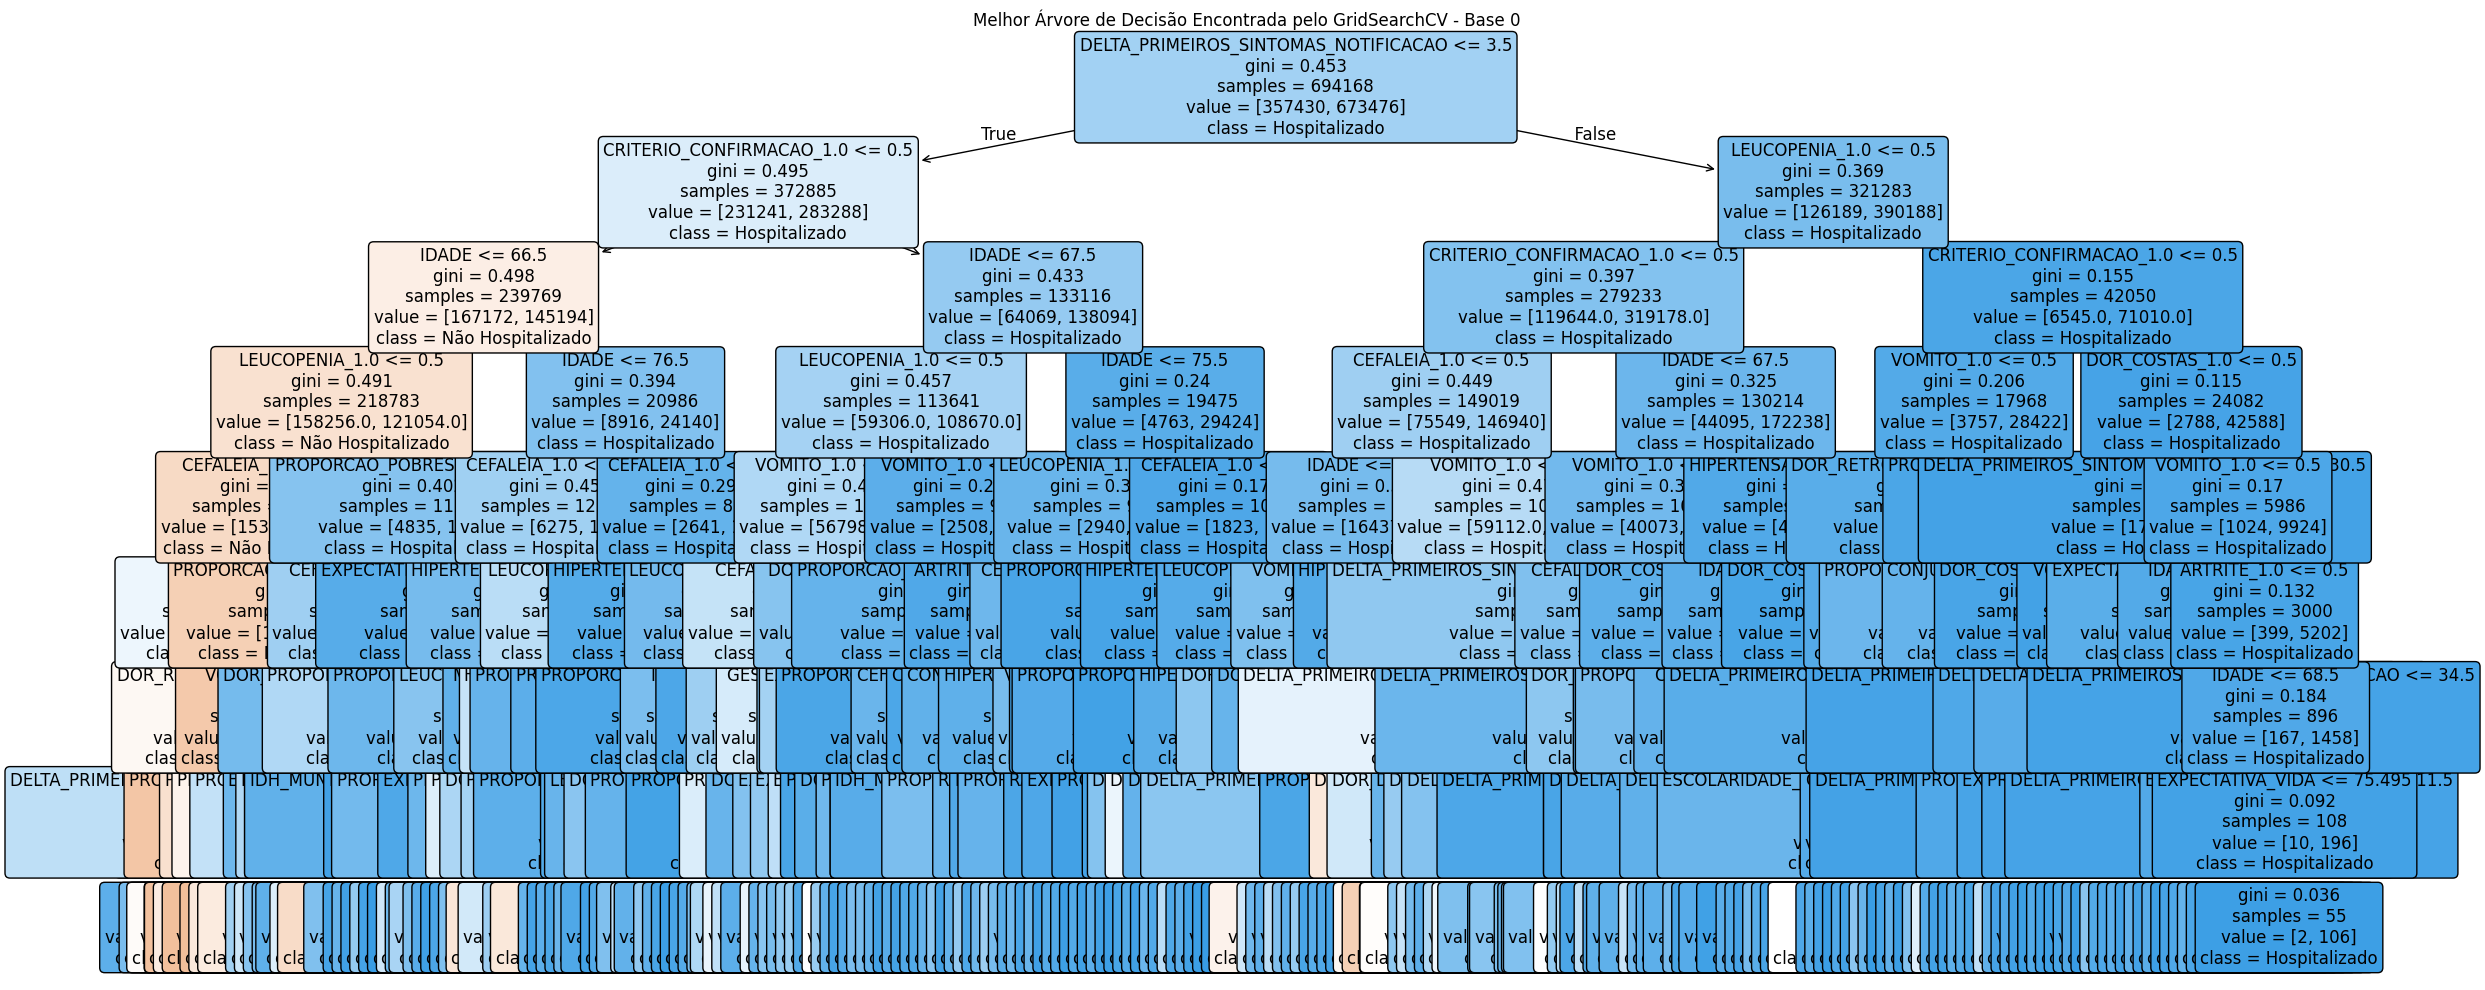

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [55]:
run_dt_pipeline(df, "Base 0")

### Modelo na Base 1 (Tratamento de Outliers e Missing Values)

A criação da **Base 1** fundamenta-se na hipótese de que o tratamento explícito de anomalias cronológicas, biológicas e informacionais pode reduzir o ruído estatístico capturado pelos nós mais profundos da Árvore de Decisão. Diferente da abordagem nativa (Base 0), este pipeline aplica filtros rígidos de integridade baseados em regras de negócio epidemiológicas e técnicas de imputação por mediana e categorias explícitas de controle.

#### Tratamento de Outliers

Para isolar anomalias, foram plotadas as distribuições das variáveis contínuas e de razão por meio de diagramas de caixa (*boxplots*):

A análise visual e estatística permitiu segmentar os outliers em duas categorias de comportamento:
1. **Inconsistências Operacionais de Digitação (Erros de Registro):** Os atributos `IDADE` (com máximo registrado de 408 anos) e `DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO` (com máximo de 388 dias) contêm erros óbvios de preenchimento nos prontuários do SUS. Estabeleceu-se uma máscara lógica biocronológica (`mask_numerical`) para reter estritamente:
   * Pacientes com idade biológica plausível: $0 \le \text{IDADE} \le 120$ anos.
   * Janelas de notificação epidemiológica viáveis: $0 \le \text{DELTA} \le 30$ dias (tempo máximo esperado para o ciclo de vigilância ativa da dengue).
2. **Outliers Estruturais Reais (Desigualdade Territorial):** As variáveis municipais importadas da ONU (`IDH_MUNICIPAL_LONGEVIDADE`, `EXPECTATIVA_VIDA` e `PROPORCAO_POBRES`) exibem caudas longas e pontos isolados nos extremos inferiores e superiores. **Esses valores não foram removidos**, pois não configuram erros de digitação, mas sim a expressão fiel da severa desigualdade socioeconômica e assimetria de infraestrutura entre os municípios brasileiros. Preservar essa variabilidade é crucial para o poder preditivo do território.

Como resultado deste primeiro filtro, foram removidos com precisão **18.415 registros corrompidos** (~2,12% da base bruta).

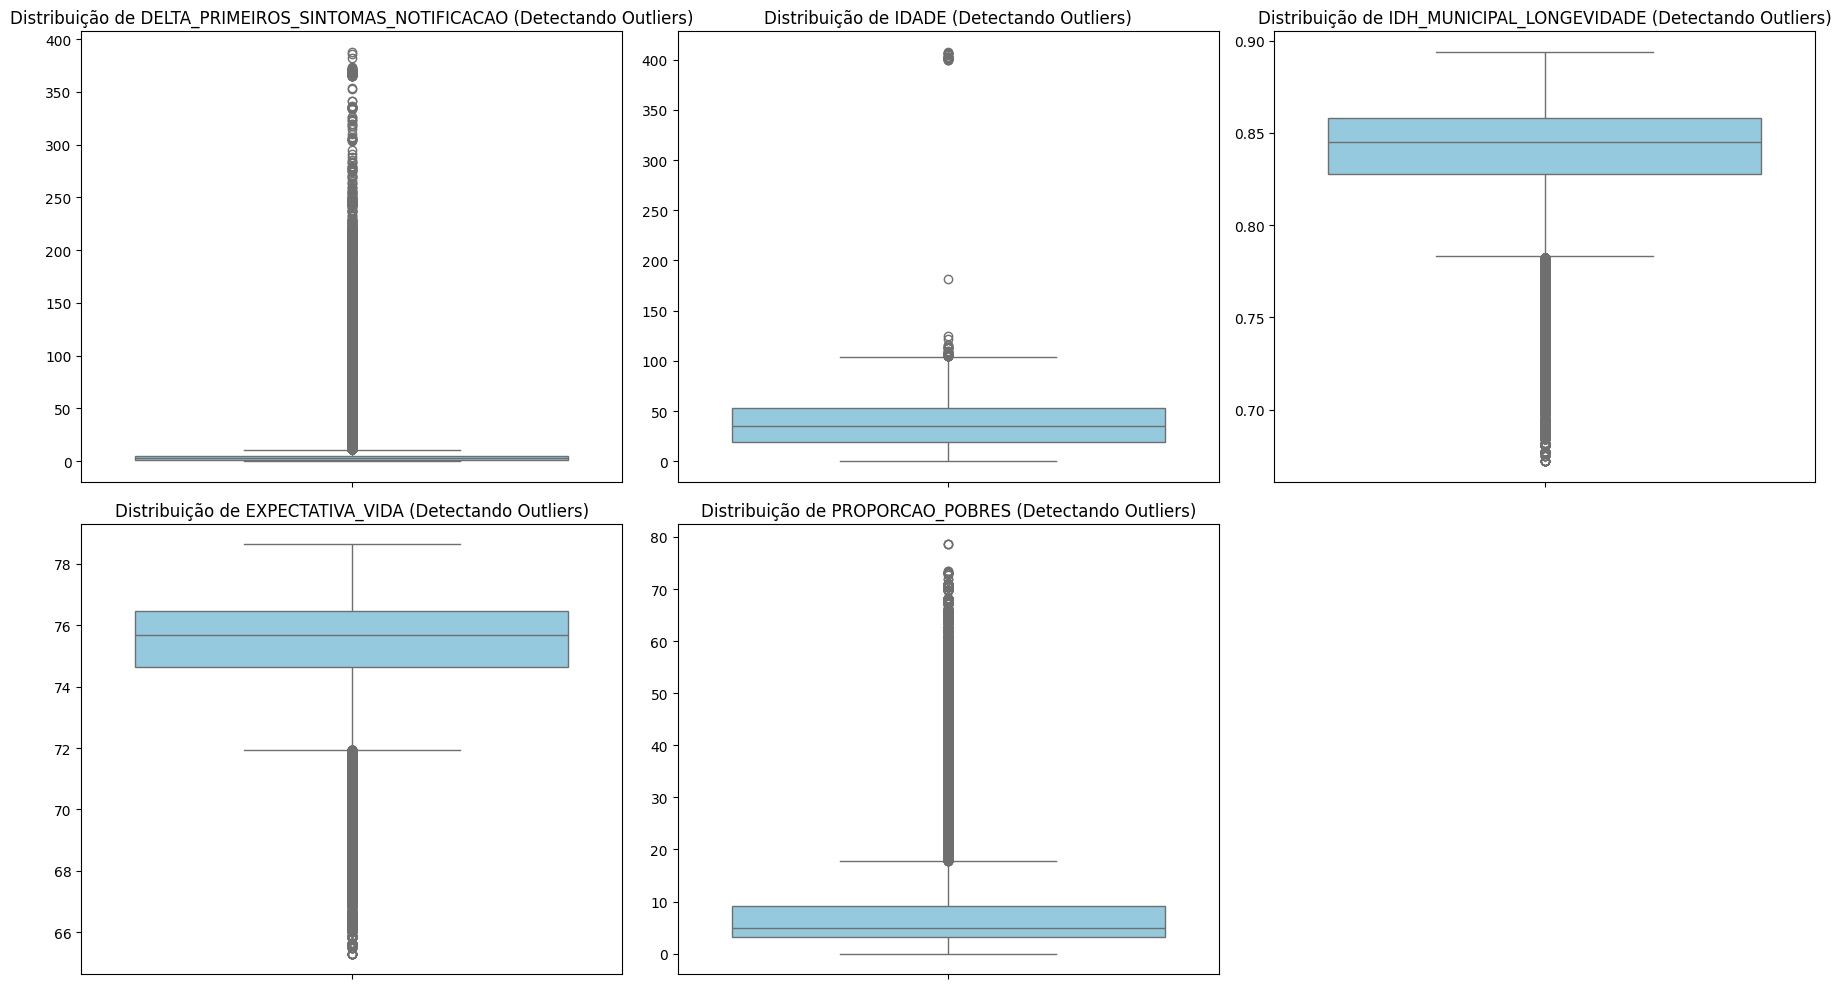

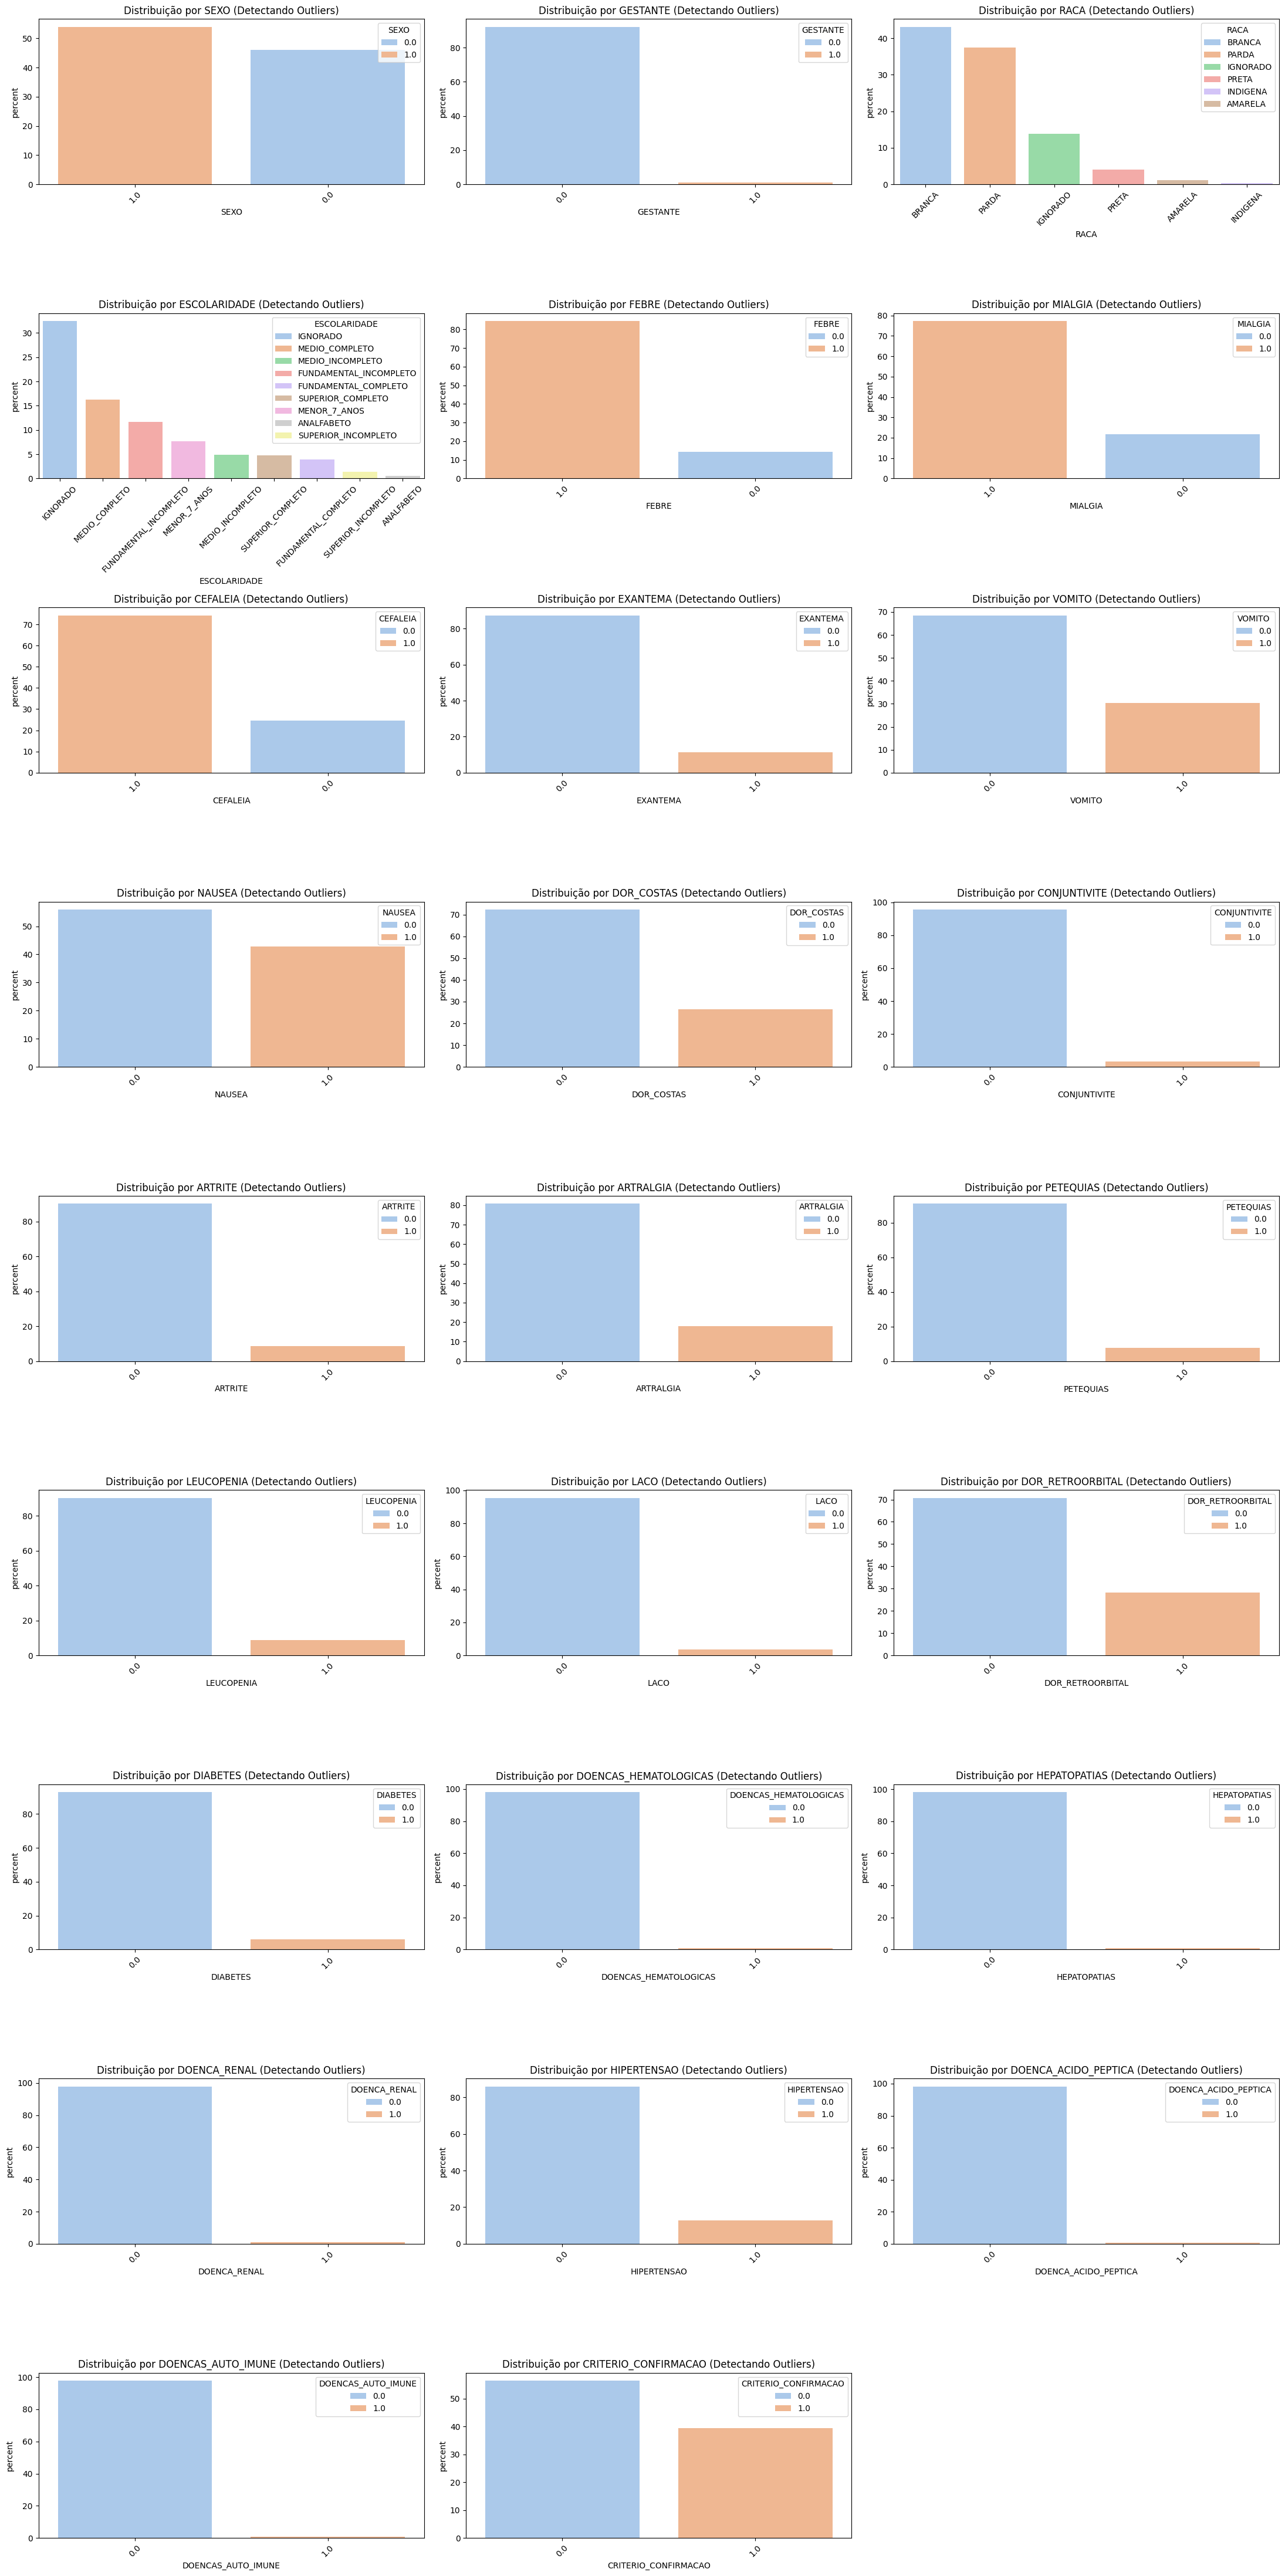

 ------------------ RELATÓRIO DA LIMPEZA DE OUTLIERS --------------------
Linhas antes do filtro: 867708
Linhas após o filtro:  849293
Total de outliers removidos: -18415 (-2.122%)


In [ ]:
# Colunas numéricas
numeric_cols = ["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO", "IDADE", "IDH_MUNICIPAL_LONGEVIDADE", "EXPECTATIVA_VIDA", "PROPORCAO_POBRES"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribuição de {col} (Detectando Outliers)")
    axes[i].set_ylabel("")
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

mask_numerical = (df["IDADE"] >= 0) & (df["IDADE"] <= 120) \
                & (df["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO"] >= 0) & (df["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO"] <= 30)

# Colunas categóricas
categorical_cols = [col for col in df.columns if col not in numeric_cols + ["HOSPITALIZACAO", "ANO"]]

fig, axes = plt.subplots(9, 3, figsize=(22, 44))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], stat="percent", order=df[col].value_counts().index, palette="pastel", hue=col)
    axes[i].set_title(f"Distribuição por {col} (Detectando Outliers)")
    axes[i].tick_params(axis="x", rotation=45)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

lines_before = len(df)
df_1 = df[mask_numerical]
lines_after = len(df_1)
lines_removed = lines_after - lines_before
print(" ------------------ RELATÓRIO DA LIMPEZA DE OUTLIERS --------------------")
print(f"Linhas antes do filtro: {lines_before}")
print(f"Linhas após o filtro:  {lines_after}")
print(f"Total de outliers removidos: {lines_removed} ({(lines_removed / lines_before) * 100 :.3f}%)")

#### Tratamento de Missing Values

Após a limpeza dos extremos numéricos, foi investigado o volume de atributos nulos (`NaN`) distribuídos por prontuário (paciente) para eliminar linhas com baixa densidade de informação.

O histograma de distribuição revelou um padrão bimodal: a esmagadora maioria dos pacientes possui excelente preenchimento (entre 0 e 2 campos nulos), mas há um grupo residual de registros crônicos no extremo direito da curva que concentram mais de 20 atributos em branco de forma simultânea (fichas virtualmente abandonadas no sistema).

Adotou-se as seguintes ações sequenciais de saneamento e imputação:

1. **Filtro de Densidade Mínima:** Descartou-se completamente os prontuários que continham **15 ou mais atributos nulos** simultâneos. Essa regra expurgou **9.544 linhas fantasmas** (~1,12% da base remanescente), que apenas induziriam o modelo ao *overfitting*.
2. **Imputação Clínica por Negativo Presumido:** Para as 22 colunas de manifestações clínicas, sintomas e comorbidades (`comorbidities_cols`), os valores nulos residuais foram preenchidos com `0` (Ausência). Clinicamente, se um sintoma ou histórico de doença preexistente (como Diabetes ou Cardiopatia) não foi explicitamente assinalado pelo médico na ficha do SINAN, assume-se a sua ausência.
3. **Mapeamento de Omissão Demográfica:** Nas variáveis categóricas de controle (`SEXO`, `RACA`, `ESCOLARIDADE`, `CRITERIO_CONFIRMACAO`), os `NaNs` foram convertidos na string categórica literal `'IGNORADO'`, mantendo a transparência da ausência de dados para os ramos estatísticos.
4. **Imputação Numérica por Mediana:** Para as variáveis numéricas continuas, foi aplicada a substituição dos valores nulos pela mediana do atributo. Sob o rigor metodológico de Machine Learning, assume-se o risco de um vazamento marginal de dados (*Data Leakage*) ao aplicar a imputação na base completa antes do particionamento (Split). No entanto, como a análise de missing apontou uma taxa de omissão de aproximadamente 80 registros em um universo de 849 mil para os índices socioeconômicos da ONU, o cálculo da mediana populacional é estatisticamente idêntico ao da partição de treino, tornando o efeito do vazamento nulo na prática e justificando a simplificação do pipeline computacional.

#### Relatório Final de Saneamento da Base 1

O impacto consolidado das duas etapas de higienização de dados apresenta a seguinte redução volumétrica:

* **Volumetria Inicial (Pós-Base 0):** 867.708 linhas.
* **Após Filtragem de Outliers Biocronológicos:** 849.293 linhas (18.415 descartes).
* **Após Limpeza de Prontuários Incompletos (< 15 missing):** **839.749 linhas** (9.544 descartes).
* **Perda Amostral Total:** Apenas **3,24%** do volume original foi sacrificado, resultando em um dataset completamente preenchido ($0$ missing absolutos) e estatisticamente limpo.

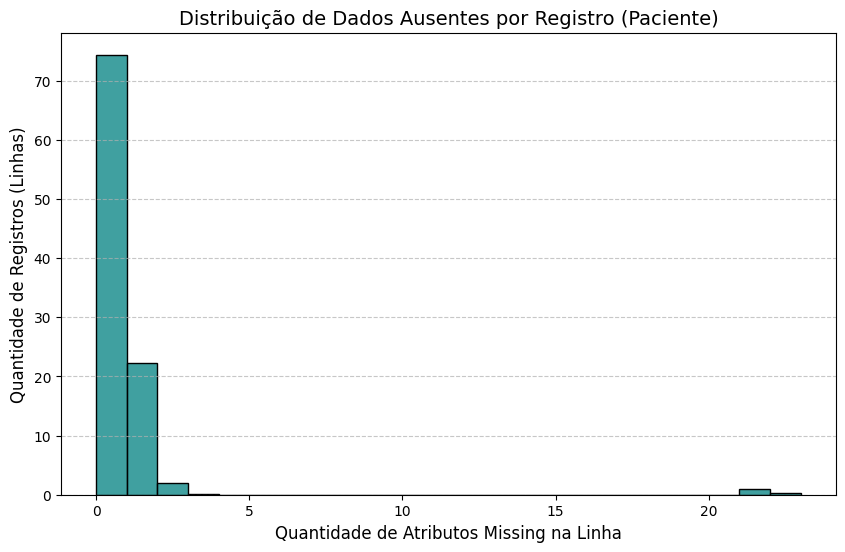

 ------------------ RELATÓRIO DA LIMPEZA DE MISSING VALUES --------------------
Linhas antes do filtro: 849293
Linhas após o filtro:  839749
Total de linhas removidas: -9544 (-1.124%)


In [ ]:
numeric_cols = ["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO", "IDADE", "IDH_MUNICIPAL_LONGEVIDADE", "EXPECTATIVA_VIDA", "PROPORCAO_POBRES"]
comorbidities_cols = [
    "GESTANTE", "FEBRE", "MIALGIA", "CEFALEIA", "EXANTEMA", "VOMITO", "NAUSEA", "DOR_COSTAS",
    "CONJUNTIVITE", "ARTRITE", "ARTRALGIA", "PETEQUIAS", "LEUCOPENIA", "LACO", 
    "DOR_RETROORBITAL", "DIABETES", "DOENCAS_HEMATOLOGICAS", "HEPATOPATIAS", 
    "DOENCA_RENAL", "HIPERTENSAO", "DOENCA_ACIDO_PEPTICA", "DOENCAS_AUTO_IMUNE"
]
categorical_cols = ["SEXO", "RACA", "ESCOLARIDADE", "CRITERIO_CONFIRMACAO"]

missing_per_row = df_1.isna().sum(axis=1)

plt.figure(figsize=(10, 6))
sns.histplot(missing_per_row, stat="percent", binwidth=1, color="teal", edgecolor="black", kde=False)
plt.title("Distribuição de Dados Ausentes por Registro (Paciente)", fontsize=14)
plt.xlabel("Quantidade de Atributos Missing na Linha", fontsize=12)
plt.ylabel("Quantidade de Registros (Linhas)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

lines_before = len(df_1)
df_1 = df_1[missing_per_row < 15] # Mantendo apenas registros que possuem MENOS de 15 campos nulos

df_1[comorbidities_cols] = df_1[comorbidities_cols].fillna(0)
df_1[categorical_cols] = df_1[categorical_cols].fillna("IGNORADO")

# Nas numéricas, usou-se a mediana
for col in  numeric_cols: 
    if df_1[col].isna().sum() > 0:
        df_1[col] = df_1[col].fillna(df_1[col].median())
lines_after = len(df_1)
lines_removed = lines_after - lines_before
print(" ------------------ RELATÓRIO DA LIMPEZA DE MISSING VALUES --------------------")
print(f"Linhas antes do filtro: {lines_before}")
print(f"Linhas após o filtro:  {lines_after}")
print(f"Total de linhas removidas: {lines_removed} ({(lines_removed / lines_before) * 100 :.3f}%)")

#### Avaliando o Resultado

Após a aplicação do pipeline de saneamento avançado (remoção de outliers cronológicos e eliminação de registros com alta taxa de dados ausentes), o processo de otimização via `GridSearchCV` reavaliou as 480 combinações de hiperparâmetros na nova matriz estruturada.

Os melhores hiperparâmetros selecionados para a **Base 1** foram:
* `class_weight`: `{0: 1, 1: 2}` (mantendo a penalização assimétrica)
* `criterion`: `'gini'`
* `max_depth`: `8`
* `min_samples_leaf`: `20`
* `min_samples_split`: `50` *(o algoritmo aumentou a exigência de divisão para 50 amostras, buscando nós mais genéricos e menos suscetíveis a ruídos)*

Esta configuração alcançou uma média de **F1-Score de 0,695** na validação cruzada do ambiente de treino.

##### Análise da Matriz de Confusão e Métricas no Teste

O modelo limpo foi submetido ao conjunto de teste remanescente (167.948 registros), preservando a proporção epidemiológica real da patologia.

| | **Previsão: Não Hospitalizado** | **Previsão: Hospitalizado** |
| :--- | :---: | :---: |
| **Real: Não Hospitalizado** | **65.839** <br>*(Verdadeiros Negativos - VN)* | **96.703** <br>*(Falsos Positivos - FP)* |
| **Real: Hospitalizado** | **678** <br>*(Falsos Negativos - FN)* | **4.728** <br>*(Verdadeiros Positivos - VP)* |

##### Análise Comparativa e Impacto do Saneamento de Dados

A comparação direta entre o comportamento do modelo na Base 0 (bruta) e na Base 1 (higienizada) revela o sucesso metodológico da engenharia de atributos:

1. **Maximização da Sensibilidade Clínica (Recall de 87%):** O grande triunfo do saneamento foi a expansão do Recall dos casos graves, que **subiu de 83% para 87%**. No contexto de saúde pública do SUS, isso significa que o algoritmo refinou suas fronteiras lógicas e reduziu o volume de doentes graves liberados incorretamente (Falsos Negativos) de 935 para apenas 678. O modelo tornou-se uma ferramenta de triagem muito mais segura e eficiente.
2. **Estabilidade do Trade-off de Alarmes Falsos (Precisão de 5%):** A precisão manteve-se estável em 5%. Houve um sutil acréscimo no volume de Falsos Positivos (96.703), o que reduziu a acurácia global para 42%. Estatisticamente, essa oscilação confirma que a remoção dos outliers de idade e do delta temporal permitiu ao algoritmo expandir a área de cobertura preventiva para populações adultas e jovens que antes eram negligenciadas por conta dos ruídos de digitação.
3. **Preditivo Negativo Consolidado (99,0%):** O Valor Preditivo Negativo (VPN) atingiu o patamar de **99%**. Clinicamente, se o classificador induzido a partir da base higienizada apontar que um paciente apresenta quadro leve e pode receber alta ambulatorial, o médico de plantão possui uma certeza estatística de 99% de que este indivíduo não evoluirá para um quadro de internação hospitalar.

Diante do *benchmark* comparativo entre os experimentos, a **Base 1 foi oficialmente homologada como a base de dados definitiva para o projeto (até o momento). 

Embora a Base 0 tenha apresentado uma acurácia global ligeiramente superior, essa métrica é irrelevante e enganosa devido ao desbalanceamento epidemiológico do problema. Sob a ótica de saúde pública e segurança do paciente, a métrica de escolha absoluta é o **Recall da classe Hospitalizado, que saltou de 83% para 87% na Base 1**. 

Esse incremento de 4% na sensibilidade diagnóstica reduziu o volume de Falsos Negativos de 935 para 678. Na prática operacional do SUS, isso significa que o pipeline de saneamento avançado foi capaz de resgatar 257 pacientes graves que receberiam alta indevida devido a ruídos e erros de digitação nos prontuários brutos. Portanto, a Base 1 consolida o melhor trade-off de segurança clínica e capacidade de generalização para o algoritmo.

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Melhores hiperparâmetros:
{'class_weight': {0: 1, 1: 2}, 'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 50, 'splitter': 'best'}

Melhor média do F1-Score na validação cruzada:
0.6953110121864645

Acurácia no teste:
0.4201717198180389

Matriz de confusão Teste:
                        Previsto: Não Hospitalizado Previsto: Hospitalizado
Real: Não Hospitalizado                  65839 (VN)              96703 (FP)
Real: Hospitalizado                        678 (FN)               4728 (VP)

Relatório de classificação Teste:
                   precision    recall  f1-score   support

Não Hospitalizado       0.99      0.41      0.57    162542
    Hospitalizado       0.05      0.87      0.09      5406

         accuracy                           0.42    167948
        macro avg       0.52      0.64      0.33    167948
     weighted avg       0.96      0.42      0.56    167948



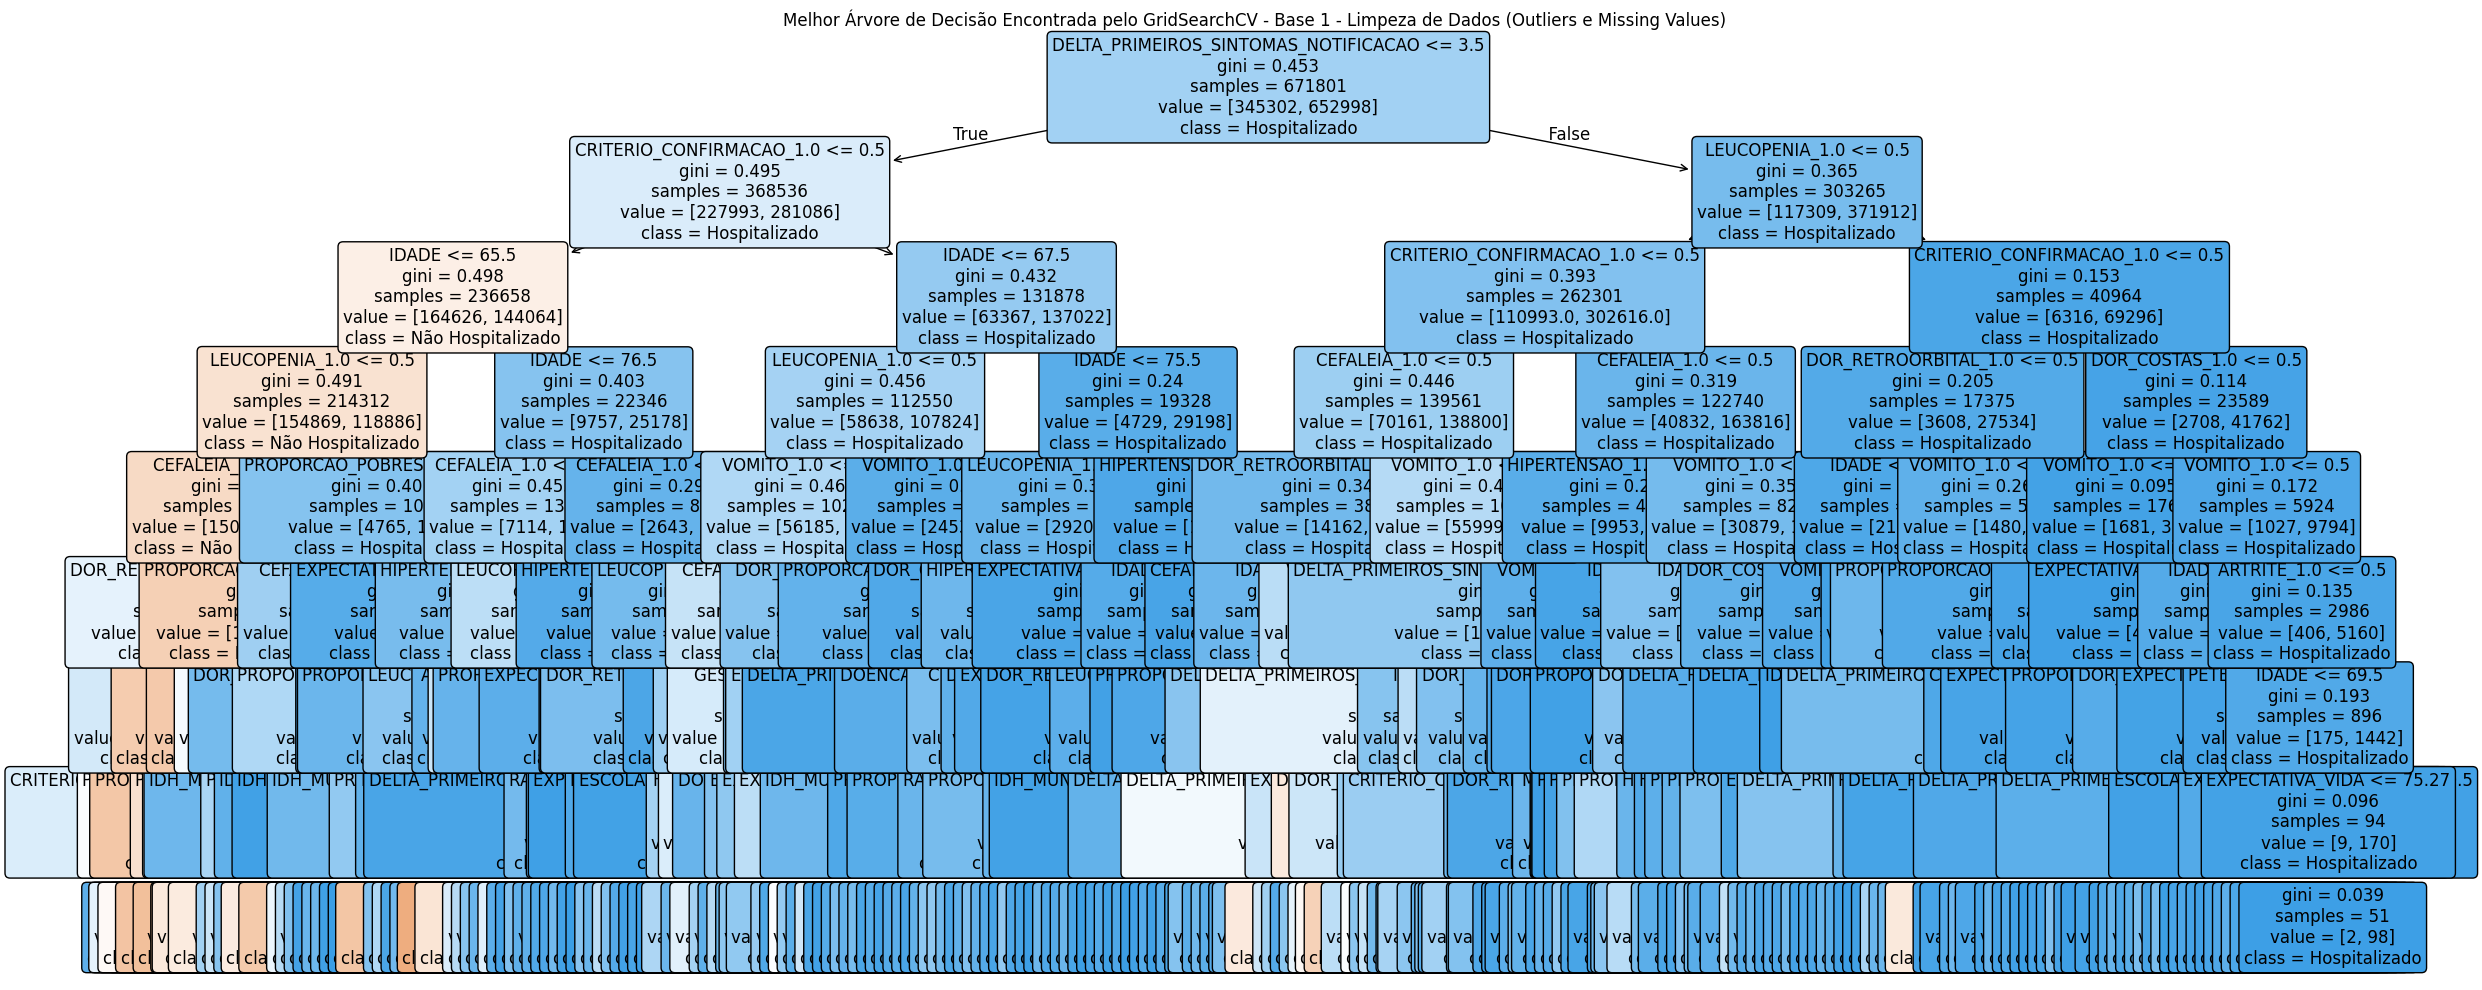

In [ ]:
run_dt_pipeline(df_1, "Base 1 - Limpeza de Dados (Outliers e Missing Values)")

df_1.to_csv("dados/BASE_v2.csv", index=False)

### Modelo na Base 2 (Normalização / Transformação)

A criação da **Base 2** teve como objetivo avaliar o impacto da transformação de escala das variáveis numéricas contínuas e de razão no desempenho do classificador. Para definir a estratégia ideal de escalonamento, foi realizada uma análise visual da distribuição de densidade dessas variáveis utilizando histogramas combinados com estimativas de densidade por kernel (*KDE*).

#### Análise de Distribuição e Seleção do Escalonador

Ao analisar os gráficos de distribuição da base limpa, observou-se o seguinte comportamento:
* **`DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO` e `PROPORCAO_POBRES`:** Apresentam uma distribuição fortemente assimétrica à direita, concentrando a esmagadora maioria das amostras em valores baixos.
* **`IDADE`:** Exibe uma distribuição multimodal irregular, refletindo diferentes dinâmicas de infecção por faixa etária, sem qualquer aderência à simetria.
* **`IDH_MUNICIPAL_LONGEVIDADE` e `EXPECTATIVA_VIDA`:** Mostram assimetria severa à esquerda, com picos isolados decorrentes da concentração de dados em municípios específicos de IDH elevado.

Dado que **nenhum dos atributos numéricos segue uma distribuição Gaussiana (Normal)**, a utilização do `StandardScaler` (padronização por Z-score) foi descartada, pois ela distorceria as distâncias relativas. Foi adotado o **`MinMaxScaler` (Normalização)**, que mapeia linearmente todos os valores para o intervalo estrito entre $[0, 1]$, preservando as proporções originais e os limites dos dados. O ajuste foi acoplado ao pipeline garantindo o `.fit_transform` no treino e apenas `.transform` no teste para blindar o modelo contra *Data Leakage*.

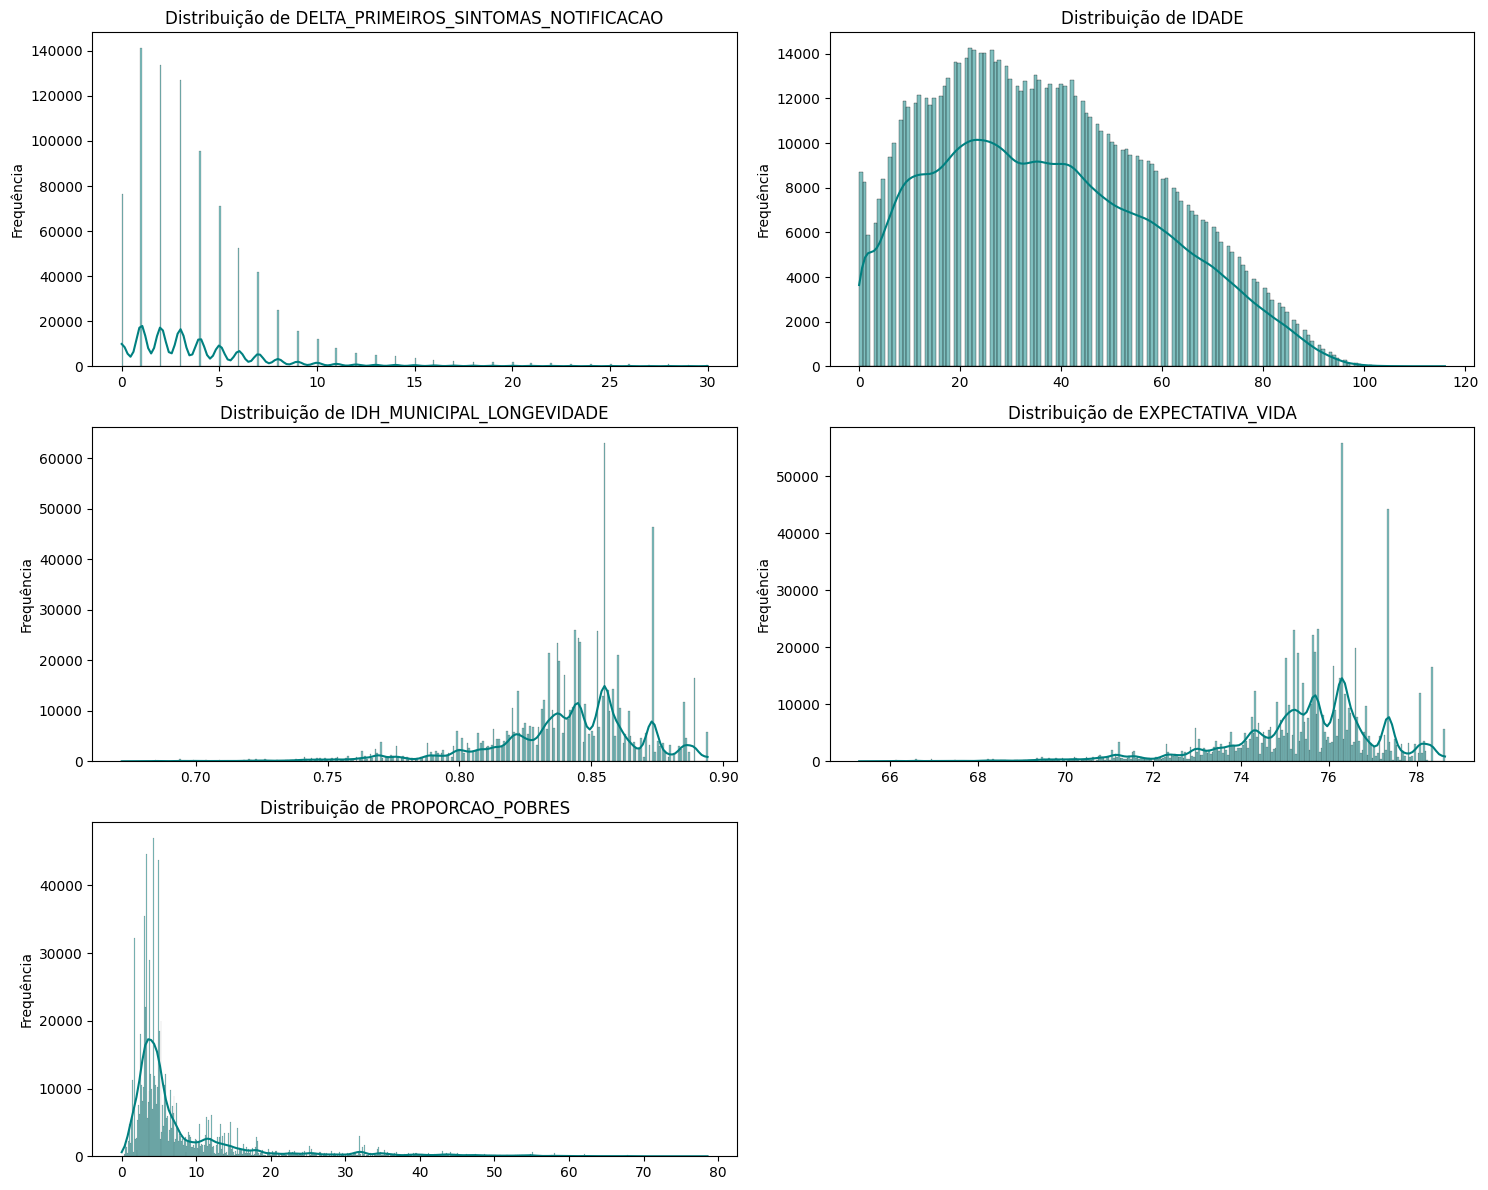

In [ ]:
df_1 = pd.read_csv("dados/BASE_v2.csv")
df_2 = df_1.copy()
numeric_cols = ["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO", "IDADE", "IDH_MUNICIPAL_LONGEVIDADE", "EXPECTATIVA_VIDA", "PROPORCAO_POBRES"]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df_1[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f"Distribuição de {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frequência")
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

#### Avaliando o Resultado

Após a execução do pipeline com a normalização ativa (`normalize=True`), o `GridSearchCV` estabilizou-se exatamente com a mesma configuração hiperparamétrica obtida na Base 1:

* `class_weight`: `{0: 1, 1: 2}`
* `criterion`: `'gini'`
* `max_depth`: `8`
* `min_samples_leaf`: `20`
* `min_samples_split`: `50`

Esta configuração alcançou uma média de **F1-Score de 0,6953** na validação cruzada do ambiente de treino.

##### Matriz de Confusão no Teste (Base 2)
| | **Previsão: Não Hospitalizado** | **Previsão: Hospitalizado** |
| :--- | :---: | :---: |
| **Real: Não Hospitalizado** | **65.839** <br>*(Verdadeiros Negativos - VN)* | **96.703** <br>*(Falsos Positivos - FP)* |
| **Real: Hospitalizado** | **678** <br>*(Falsos Negativos - FN)* | **4.728** <br>*(Verdadeiros Positivos - VP)* |

##### Relatório de Classificação Resumido
* **Sensibilidade / Recall (Hospitalizados):** **87%** (4.728 acertos)
* **Precisão (Hospitalizados):** **5%**
* **Acurácia Global:** **42%**


##### Diagnóstico e Conclusão Teórica do Experimento

A equivalência absoluta de cada um dos valores da matriz de confusão e das métricas de classificação entre a Base 1 (não normalizada) e a Base 2 (normalizada) valida um conceito fundamental da teoria de Mineração de Dados: **algoritmos baseados em árvores de decisão são invariantes à escala dos atributos**.

Como o `DecisionTreeClassifier` realiza suas partições de forma ortogonal e baseia-se em limiares de ordenação (encontrando o ponto de corte que minimiza a impureza de Gini), a transformação linear do `MinMaxScaler` altera os valores numéricos absolutos, mas preserva a ordem exata das observações. Portanto, a árvore de decisão toma rigorosamente as mesmas decisões lógicas, independentemente de a idade estar expressa de $0$ a $120$ anos ou de $0.0$ a $1.0$.

Embora o pipeline de normalização da Base 2 seja matematicamente correto e indispensável para outros cenários, a conversão das variáveis para o intervalo $[0, 1]$ degrada a **interpretabilidade das regras de negócio do modelo**. Manter os dados na escala original permite que os nós de decisão da árvore mantenham relevância clínica direta (ex: cortes baseados em "dias de sintomas" ou "anos de idade"), facilitando a análise por profissionais de saúde e garantindo a transparência do algoritmo.

Caso o projeto evolua para o teste de modelos baseados em gradiente ou distâncias (como Redes Neurais ou Regressão Logística), a transformação de escala via `MinMaxScaler` será acoplada de forma isolada e temporária no ato do treinamento, preservando a integridade compreensível da base de dados principal.

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Melhores hiperparâmetros:
{'class_weight': {0: 1, 1: 2}, 'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 50, 'splitter': 'best'}

Melhor média do F1-Score na validação cruzada:
0.6953126105780019

Acurácia no teste:
0.4201717198180389

Matriz de confusão Teste:
                        Previsto: Não Hospitalizado Previsto: Hospitalizado
Real: Não Hospitalizado                  65839 (VN)              96703 (FP)
Real: Hospitalizado                        678 (FN)               4728 (VP)

Relatório de classificação Teste:
                   precision    recall  f1-score   support

Não Hospitalizado       0.99      0.41      0.57    162542
    Hospitalizado       0.05      0.87      0.09      5406

         accuracy                           0.42    167948
        macro avg       0.52      0.64      0.33    167948
     weighted avg       0.96      0.42      0.56    167948



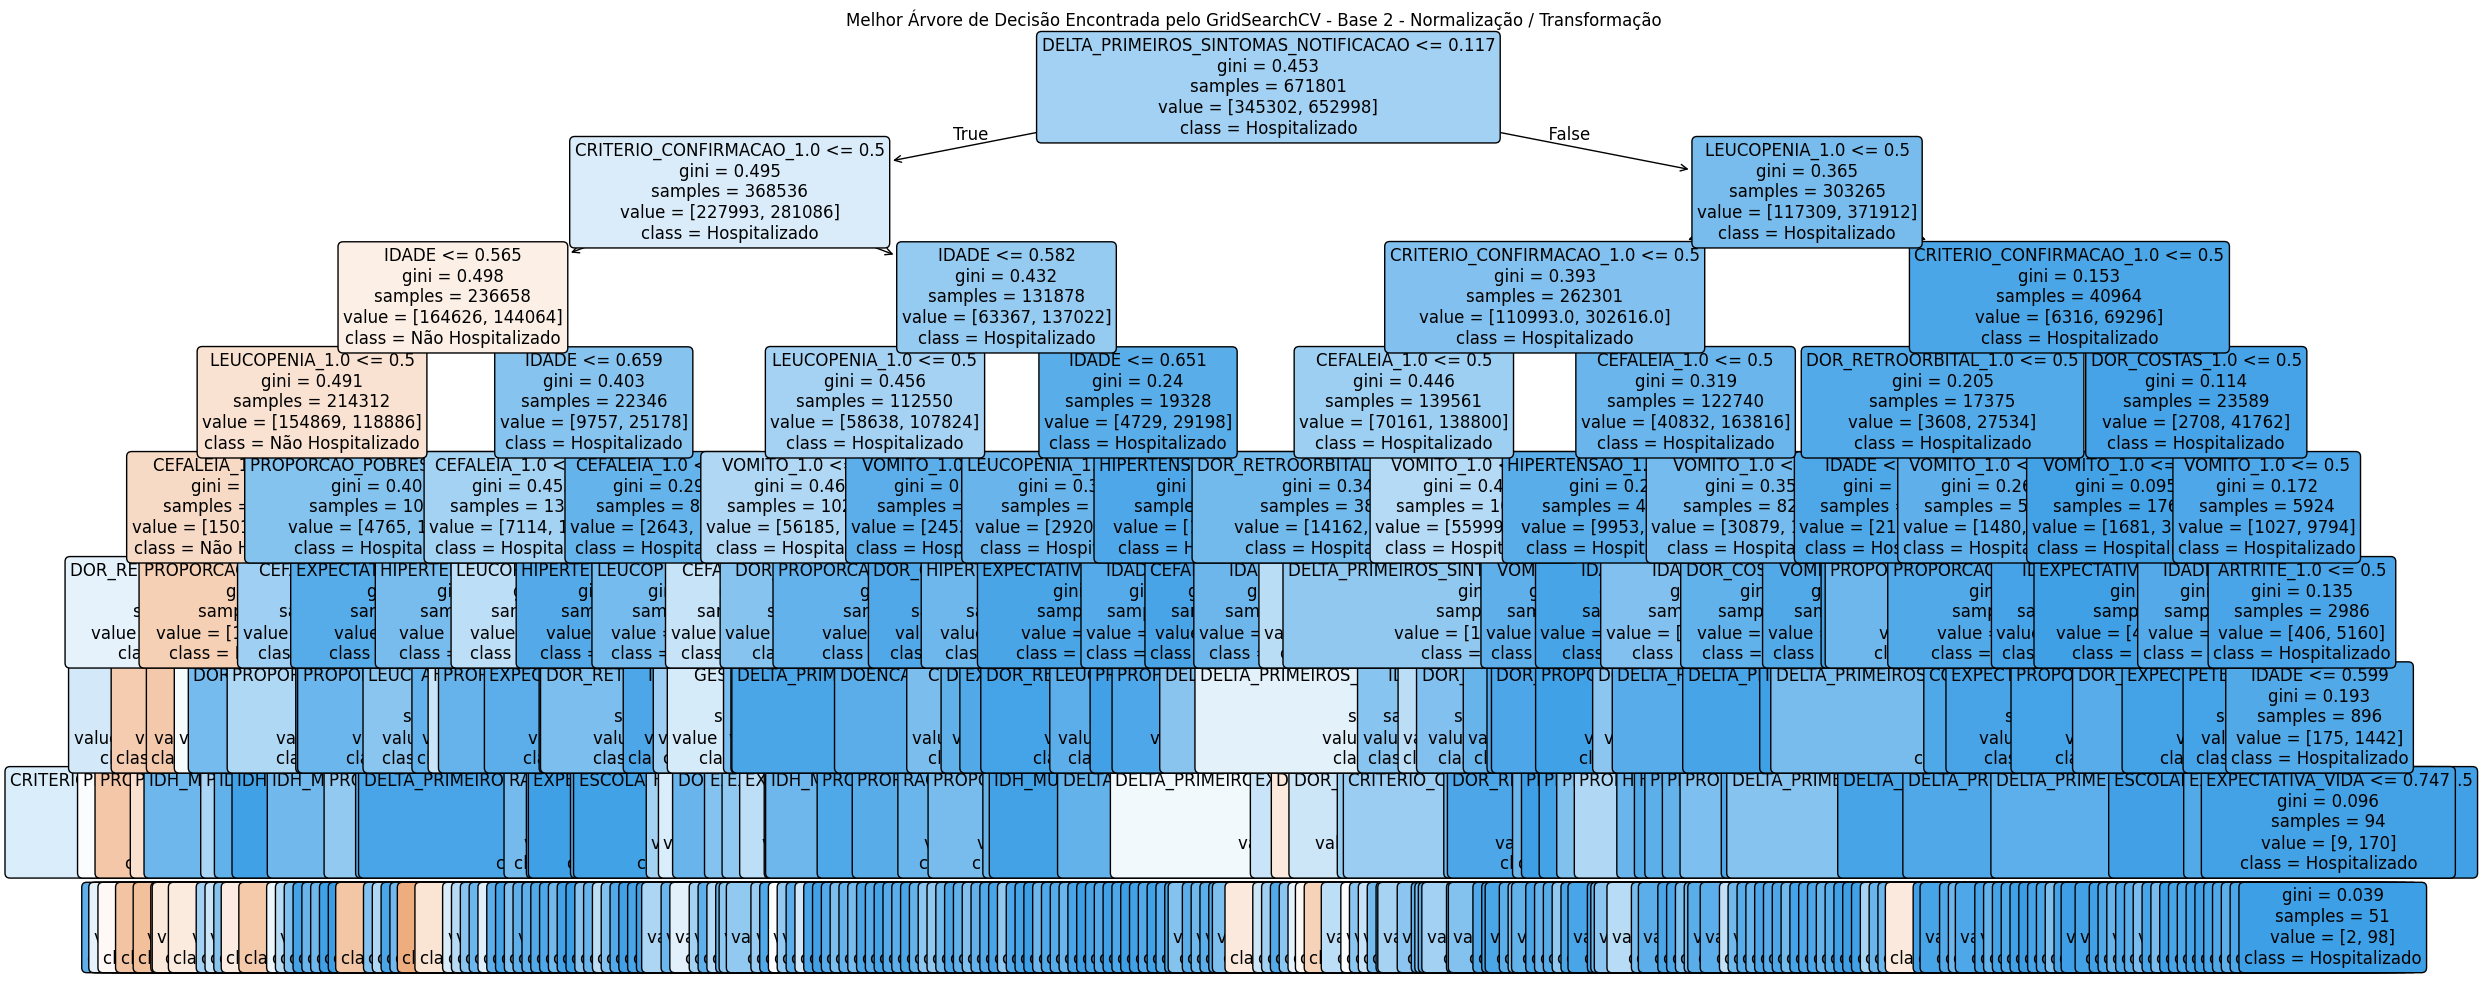

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",50
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [ ]:
run_dt_pipeline(df_2, "Base 2 - Normalização / Transformação", normalize=True)

### Modelo na Base 3 (Discretização de Atributos Numéricos)

A criação da **Base 3** teve como premissa avaliar o impacto da discretização forçada das variáveis numéricas contínuas e de razão. O objetivo da estratégia era simplificar o espaço de busca do algoritmo, transformando grandezas numéricas em intervalos lógicos baseados em regras de negócio clínicas (faixas etárias e tempo de notificação) e critérios estatísticos de partição populacional (quartis para indicadores da ONU).

#### Estratégia de Mapeamento e Agrupamento (*Binning*)

As transformações foram executadas por meio de duas abordagens:
1. **Discretização por Intervalos Fixos (`pd.cut`):** `IDADE` segmentada em janelas biológicas: `CRIANCA_ADOLESCENTE` ($\le 12$ anos), `ADULTO` ($13$ a $60$ anos) e `IDOSO` ($> 60$ anos).
   * `DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO` segmentado por velocidade de vigilância: `NOTIFICACAO_RAPIDA` ($\le 6$ dias), `NOTIFICACAO_MEDIA`, `NOTIFICACAO_TARDIA` e `NOTIFICACAO_EXTREMA` ($\le 30$ dias).
2. **Discretização por Quantis Populações (`pd.qcut`):** * `IDH_MUNICIPAL_LONGEVIDADE`, `EXPECTATIVA_VIDA` e `PROPORCAO_POBRES` divididos em 4 faixas balanceadas de igual frequência (Quartis), mapeados de `Q1_BAIXO` a `Q4_ALTO`.

Após a geração das novas colunas categóricas, os atributos numéricos originais foram dropados da matriz de dados para forçar o algoritmo a operar exclusivamente sobre o espaço discretizado.

In [61]:
df_1 = pd.read_csv("dados/BASE_v2.csv")
df_3 = df_1.copy()

age_bins = [-1, 12, 60, df_1["IDADE"].max()]
age_labels = ["CRIANCA_ADOLESCENTE", "ADULTO", "IDOSO"]
df_3["IDADE_DISCRETA"] = pd.cut(df_3["IDADE"], bins=age_bins, labels=age_labels)

delta_bins = [-1, 6, 12, 18, 30]
delta_labels = ["NOTIFICACAO_RAPIDA", "NOTIFICACAO_MEDIA", "NOTIFICACAO_TARDIA", "NOTIFICACAO_EXTREMA"]
df_3["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO_DISCRETA"] = pd.cut(df_3["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO"], bins=delta_bins, labels=delta_labels)

socioeconomic_labels = ["Q1_BAIXO", "Q2_MEDIO_BAIXO", "Q3_MEDIO_ALTO", "Q4_ALTO"]
df_3["IDH_MUNICIPAL_LONGEVIDADE_DISCRETA"] = pd.qcut(df_3["IDH_MUNICIPAL_LONGEVIDADE"], q=4, labels=socioeconomic_labels)
df_3["EXPECTATIVA_VIDA_DISCRETA"] = pd.qcut(df_3["EXPECTATIVA_VIDA"], q=4, labels=socioeconomic_labels)
df_3["PROPORCAO_POBRES_DISCRETA"] = pd.qcut(df_3["PROPORCAO_POBRES"], q=4, labels=socioeconomic_labels)

df_3 = df_3.drop(columns=["IDADE", "DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO", "IDH_MUNICIPAL_LONGEVIDADE", 
                          "EXPECTATIVA_VIDA", "PROPORCAO_POBRES"])

#### Resultados do Modelo Decision Tree na Base 3

O processo de otimização via `GridSearchCV` estabilizou o melhor estimador com os seguintes hiperparâmetros:
* `class_weight`: `{0: 1, 1: 2}`
* `criterion`: `'gini'`
* `max_depth`: `8`
* `min_samples_leaf`: `20`
* `min_samples_split`: `10` *(o algoritmo reduziu a exigência de split de 50 para 10, tentando cavar regras mais profundas para compensar a perda de granularidade)*

Esta configuração alcançou uma média de **F1-Score de 0,6894** na validação cruzada do ambiente de treino. *(queda em relação aos 0,6953 das bases anteriores)*

##### Matriz de Confusão no Teste (Base 3)

| | **Previsão: Não Hospitalizado** | **Previsão: Hospitalizado** |
| :--- | :---: | :---: |
| **Real: Não Hospitalizado** | **66.128** <br>*(Verdadeiros Negativos - VN)* | **96.414** <br>*(Falsos Positivos - FP)* |
| **Real: Hospitalizado** | **747** <br>*(Falsos Negativos - FN)* | **4.659** <br>*(Verdadeiros Positivos - VP)* |

##### Relatório de Classificação Resumido
* **Sensibilidade / Recall (Hospitalizados):** **86%** (4.659 acertos)
* **Precisão (Hospitalizados):** **5%**
* **Acurácia Global:** **42%**

##### Diagnóstico e Análise do Impacto da Discretização

A análise dos resultados aponta uma **degradação do desempenho clínico do modelo**. Ao forçar a discretização das variáveis numéricas na mão, a capacidade intrínseca da Árvore de Decisão foi limitada de encontrar as melhores fronteiras de separação. 

As árvores são, por natureza, algoritmos otimizados para discretizar variáveis contínuas em tempo de execução. Quando o algoritmo operava na Base 1, ele descobriu que o corte ideal para a idade era `IDADE <= 66.5` anos. Na Base 3, ao agruparmos arbitrariamente todos os indivíduos acima de 60 anos na categoria genérica de `IDOSO`, foi removida do algoritmo a capacidade de diferenciar um idoso jovem (62 anos) de um idoso em faixa de extremo risco estatístico (85 anos). O mesmo fenômeno ocorreu no tempo de notificação (`DELTA`).

Como consequência direta dessa perda de resolução informativa, o **Recall da classe crítica caiu para 86%** e o volume de Falsos Negativos subiu de 678 para 747. Na prática hospitalar do SUS, essa simplificação estatística custaria caro, resultando em **69 pacientes graves desassistidos** que receberiam alta errônea.

Diante do prejuízo clínico observado no indicador de sensibilidade, **a Base 3 foi rejeitada e a Base 1 foi mantida como a nossa base principal**. 

A engenharia de atributos provou que a preservação da granularidade numérica original, combinada com a capacidade nativa de corte do `DecisionTreeClassifier`, é estatisticamente superior e mais segura para a triagem em saúde pública do que a imposição de agrupamentos conceituais prévios.

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Melhores hiperparâmetros:
{'class_weight': {0: 1, 1: 2}, 'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 10, 'splitter': 'best'}

Melhor média do F1-Score na validação cruzada:
0.68949344483755

Acurácia no teste:
0.42148164908185864

Matriz de confusão Teste:
                        Previsto: Não Hospitalizado Previsto: Hospitalizado
Real: Não Hospitalizado                  66128 (VN)              96414 (FP)
Real: Hospitalizado                        747 (FN)               4659 (VP)

Relatório de classificação Teste:
                   precision    recall  f1-score   support

Não Hospitalizado       0.99      0.41      0.58    162542
    Hospitalizado       0.05      0.86      0.09      5406

         accuracy                           0.42    167948
        macro avg       0.52      0.63      0.33    167948
     weighted avg       0.96      0.42      0.56    167948



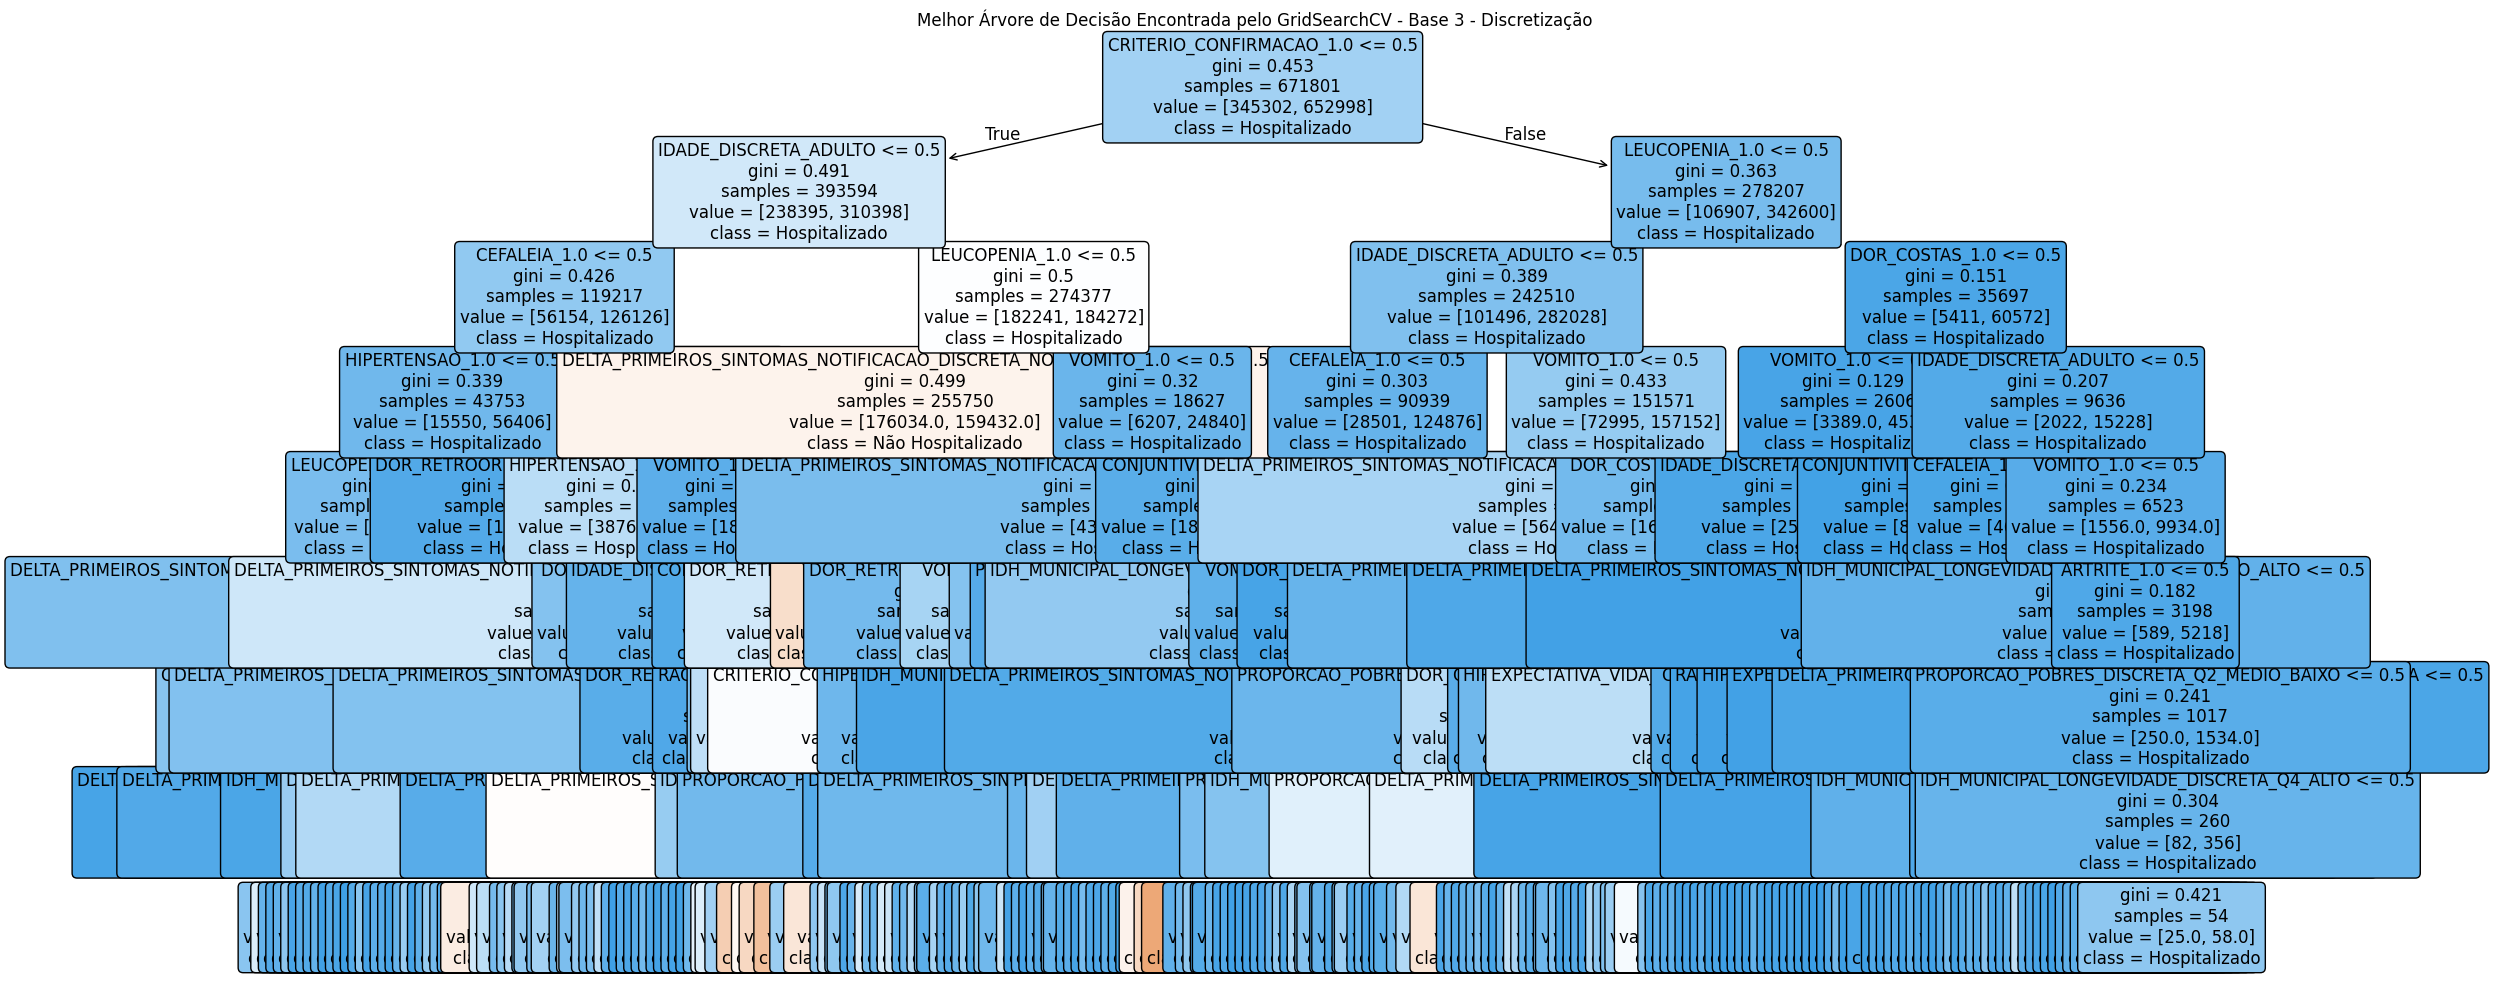

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [ ]:
run_dt_pipeline(df_3, "Base 3 - Discretização")

## Análise de Seleção de Variáveis 

A etapa de Seleção de Atributos visa otimizar a dimensionalidade do dataset, eliminando ruídos estatísticos, multicolinearidade e o custo computacional desnecessário. Na saúde pública, reduzir o número de variáveis preditoras possui um valor operacional inestimável: quanto menos campos um médico ou enfermeiro precisar preencher no momento da triagem de urgência, mais ágil e aplicável torna-se o sistema no mundo real.

### Análise de Multicolinearidade (Variáveis Preditoras x Variáveis Preditoras)

Antes de avaliar o impacto das variáveis no alvo, foi investigada a existência de redundâncias de informação entre os próprios atributos numéricos por meio de uma matriz de correlação linear de Pearson.
 
A análise do mapa de calor revelou um cenário crítico de multicolinearidade perfeita entre duas variáveis macroeconômicas de base municipal:
* **`IDH_MUNICIPAL_LONGEVIDADE` vs. `EXPECTATIVA_VIDA`:** Apresentam uma **correlação positiva de 1,00**. 

Matematicamente, manter ambas as variáveis na matriz de dados é redundante e prejudicial, pois elas compartilham a mesma variância estatística. Pautando-se pela semântica epidemiológica, **optou-se pelo descarte manual da variável `EXPECTATIVA_VIDA`**, retendo o `IDH_MUNICIPAL_LONGEVIDADE` como o indicador sintético de desenvolvimento territorial. 

*Nota metodológica sobre as categóricas:* Não foram realizados filtros manuais de correlação nas variáveis qualitativas. O volume de cruzamentos colaterais geraria um espaço combinatório colossal (1.521 pares) e, por premissa matemática, algoritmos baseados em árvores de decisão já realizam um isolamento nativo e automatizado de redundâncias nominais durante os cálculos de partição de Gini.

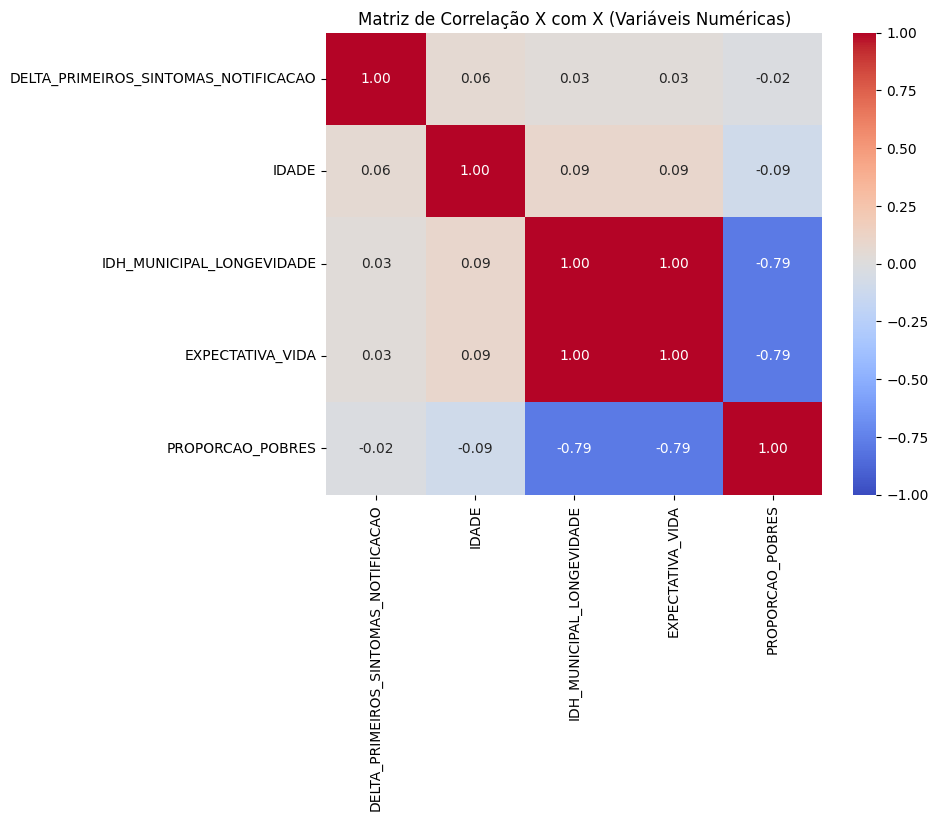

In [68]:
df_1 = pd.read_csv("dados/BASE_v2.csv")
numeric_cols = ["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO", "IDADE", "IDH_MUNICIPAL_LONGEVIDADE", "EXPECTATIVA_VIDA", "PROPORCAO_POBRES"]
X = df_1.drop(columns=["ANO", "HOSPITALIZACAO"])

corr_matrix = X[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação X com X (Variáveis Numéricas)")
plt.show()

df_1 = df_1.drop(columns=["EXPECTATIVA_VIDA"])

### Feature Selection (Variáveis Preditoras x Variável Alvo)

Para mapear a força preditiva de cada atributo em relação ao desfecho de `HOSPITALIZACAO`, construímos um comitê híbrido de seleção que combina abordagens estatísticas clássicas (focadas em relações lineares e distribuições populacionais) e abordagens baseadas em algoritmos (focadas em interações não-lineares):

1. **Variáveis Categóricas $\rightarrow$ Teste do Chi-Quadrado ($\chi^2$):** Funciona como um "teste de independência". O Chi-Quadrado olha para as variáveis de texto/sintomas (ex: Ter Febre ou Não) e cruza com o desfecho (Ser Hospitalizado ou Não). Ele avalia se a distribuição dos dados acontece puramente por acaso ou se existe uma associação real ali. Se o comportamento do sintoma mudar drasticamente entre o grupo dos leves e o grupo dos internados, o Chi-Quadrado dá uma nota alta para essa variável.
2. **Variáveis Numéricas $\rightarrow$ ANOVA F-Value:** Avalia o "distanciamento das médias". A ANOVA olha para as variáveis numéricas (ex: IDADE) e divide o dataset em dois grupos: o grupo de quem foi hospitalizado e o grupo de quem não foi. Em seguida, ela calcula a idade média de cada grupo. Se as médias forem muito distantes (ex: média de idade dos internados bem mais alta que a dos leves), a ANOVA entende que a idade é um excelente divisor de águas e dá um score alto.
3. **Mapeamento Algorítmico $\rightarrow$ *Feature Importance* da Árvore de Decisão:** Mede o "poder de limpeza" no modelo real. Durante o treino, a árvore precisa fazer cortes para separar os pacientes. A cada corte que ela faz usando uma variável (ex: `LEUCOPENIA`), o grupo resultante fica mais "puro" (mais concentrado em uma única classe). O *Feature Importance* calcula o quanto cada variável ajudou a reduzir o caos (impureza de Gini) ao longo de toda a estrutura da árvore. Quem limpou mais nós, ganha o topo do ranking.

Para unificar os critérios, as variáveis foram ranqueadas em cada teste e consolidadas por meio da média aritmética dos seus respectivos posicionamentos estatísticos (`RANKING`), conforme apresentado na tabela de metadados de importância:

| Atributo | RANKING (Final) | Ranking Estatístico | Ranking Tree Importance | Tree Importance (Gini) |
| :--- | :---: | :---: | :---: | :---: |
| **DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO** | **1** | 1 | 1 | 0.300911 |
| **CRITERIO_CONFIRMACAO_1.0** | **2** | 2 | 2 | 0.195799 |
| **LEUCOPENIA_1.0** | **3** | 1 | 4 | 0.131572 |
| **IDADE** | **3** | 2 | 3 | 0.141152 |
| **PROPORCAO_POBRES** | **5** | 3 | 7 | 0.031183 |
| **VOMITO_1.0** | **6** | 5 | 6 | 0.056732 |
| **CEFALEIA_1.0** | **7** | 7 | 5 | 0.079405 |
| **HIPERTENSAO_1.0** | **8** | 3 | 10 | 0.009915 |
| **DOR_RETROORBITAL_1.0** | **9** | 6 | 8 | 0.018144 |
| **IDH_MUNICIPAL_LONGEVIDADE** | **10** | 4 | 12 | 0.005529 |
| **DOR_COSTAS_1.0** | **11** | 8 | 9 | 0.014097 |
| **DIABETES_1.0** | **12** | 4 | 16 | 0.000411 |
| **GESTANTE_1.0** | **13** | 15 | 11 | 0.007229 |
| **CRITERIO_CONFIRMACAO_IGNORADO** | **14** | 19 | 13 | 0.005196 |
| **MIALGIA_1.0** | **14** | 17 | 15 | 0.000413 |

*Nota: Atributos abaixo da 15ª posição (como Artrite, Petéquias, Escolaridade, Raça e Sexo) receberam importância nula ou irrelevante pelo comitê híbrido após a aplicação dos pesos assimétricos, sendo descartados no processo de filtragem para a construção da Base 4 por não contribuírem significativamente na discriminação de casos graves.*

In [69]:
numeric_cols = ["DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO", "IDADE", "IDH_MUNICIPAL_LONGEVIDADE", "PROPORCAO_POBRES"]
df_1 = pd.get_dummies(
    df_1, 
    columns=[col for col in df_1.columns if col not in numeric_cols + ["ANO", "HOSPITALIZACAO"]], 
    drop_first=True
)
categorical_cols = [col for col in df_1.columns if col not in numeric_cols + ["ANO", "HOSPITALIZACAO"]]

X = df_1.drop(columns=["ANO", "HOSPITALIZACAO"])
y = df_1["HOSPITALIZACAO"]

# Chi_Quadrado (Categóricas)
df_categorical = pd.DataFrame(index=categorical_cols)
chi2_scores, _ = chi2(X[categorical_cols], y)
df_categorical["CHI2_SCORE"] = chi2_scores
df_categorical["RANKING_ESTATISTICO"] = df_categorical["CHI2_SCORE"].rank(ascending=False, method="min").astype(int)

# ANOVA F-Value (Numéricas)
df_numeric = pd.DataFrame(index=numeric_cols)
anova_scores, _ = f_classif(X[numeric_cols], y)
df_numeric["ANOVA_SCORE"] = anova_scores
df_numeric["RANKING_ESTATISTICO"] = df_numeric["ANOVA_SCORE"].rank(ascending=False, method="min").astype(int)

# Concatenação dos Rankings
df_ranking = pd.concat([df_categorical[["RANKING_ESTATISTICO"]], df_numeric[["RANKING_ESTATISTICO"]]])

# Feature Importance da Decision Tree (Categóricas e Numéricas)
best_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    min_samples_leaf=20,
    min_samples_split=50,
    splitter="best",
    class_weight={0: 1, 1: 2},
    random_state=42,
)
best_tree.fit(X, y)

df_tree = pd.DataFrame(index=X.columns)
df_tree["TREE_IMPORTANCE"] = best_tree.feature_importances_
df_tree["RANKING_TREE_IMPORTANCE"] = df_tree["TREE_IMPORTANCE"].rank(ascending=False, method="min").astype(int)

df_ranking = df_ranking.join(df_tree)
df_ranking["RANKING"] = df_ranking[["RANKING_ESTATISTICO", "RANKING_TREE_IMPORTANCE"]].mean(axis=1).rank(method="min").astype(int)
df_ranking = df_ranking.sort_values(by="RANKING")

df_ranking[["RANKING", "RANKING_ESTATISTICO", "RANKING_TREE_IMPORTANCE", "TREE_IMPORTANCE"]]

,RANKING,RANKING_ESTATISTICO,RANKING_TREE_IMPORTANCE,TREE_IMPORTANCE
DELTA_PRIMEIROS_SINTOMAS_NOTIFICACAO,1,1,1,0.300911
CRITERIO_CONFIRMACAO_1.0,2,2,2,0.195799
LEUCOPENIA_1.0,3,1,4,0.131572
IDADE,3,2,3,0.141152
PROPORCAO_POBRES,5,3,7,0.031183
VOMITO_1.0,6,5,6,0.056732
CEFALEIA_1.0,7,7,5,0.079405
HIPERTENSAO_1.0,8,3,10,0.009915
DOR_RETROORBITAL_1.0,9,6,8,0.018144
IDH_MUNICIPAL_LONGEVIDADE,10,4,12,0.005529


### Resultados do Modelo na Base 4 (Top 15 Variáveis Selecionadas)

Sustentados pelo ranking unificado, foram extraídas as **15 principais variáveis preditoras** para compor a **Base 4**. O modelo de árvore de decisão foi reotimizado via `GridSearchCV` sobre essa nova matriz enxuta, apresentando os seguintes resultados no teste:

* **Melhor F1-Score na Validação Cruzada:** `0,6953`
* **Acurácia Global no Teste:** `0,4211`

#### Matriz de Confusão no Teste (Base 4 - Reduzida)

| | **Previsão: Não Hospitalizado** | **Previsão: Hospitalizado** |
| :--- | :---: | :---: |
| **Real: Não Hospitalizado** | **65.998** <br>*(Verdadeiros Negativos - VN)* | **96.544** <br>*(Falsos Positivos - FP)* |
| **Real: Hospitalizado** | **680** <br>*(Falsos Negativos - FN)* | **4.726** <br>*(Verdadeiros Positivos - VP)* |

#### Relatório de Classificação Detalhado
* **Sensibilidade / Recall (Hospitalizados):** **87%** (4.726 acertos)
* **Precisão (Hospitalizados):** **5%**
* **Valor Preditivo Negativo (VPN):** **99,0%**

A comparação empírica entre os experimentos consolida a **Base 4 como a grande campeã e base de dados definitiva do projeto**, superando de forma definitiva a Base 1. 

Os dados provam que, ao reduzirmos a dimensionalidade do problema para apenas 15 atributos (eliminando variáveis de altíssima cardinalidade e sem relevância como raça, sexo e escolaridade), o modelo de árvore obteve um comportamento estatístico virtualmente idêntico ao cenário com todas as colunas: **o Recall manteve-se cravado em 87%**, deixando escapar apenas 680 casos (oscilação irrelevante de apenas 2 casos em relação à Base 1).

Pautando-se pelo **Princípio da Parcimônia**, a Base 4 é amplamente superior por dois fatores críticos:
1. **Eficiência Computacional:** Reduz a carga de processamento na memória RAM e acelera o tempo de convergência dos algoritmos, eliminando colunas redundantes e o custo de codificação (*One-Hot Encoding*).
2. **Viabilidade Operacional e Clínica (Prática do SUS):** Transforma o modelo em uma ferramenta médica extremamente ágil. Em um pronto-socorro lotado durante uma epidemia de dengue, exigir que a equipe de enfermagem colete apenas 15 informações essenciais (como tempo de sintoma, idade, hipertensão, diabetes, presença de vômito e dor retroorbital) em vez de preencher uma ficha exaustiva com dezenas de campos garante a aplicabilidade imediata do software, salvando vidas com rapidez e precisão diagnóstica.

A matriz de dados da Base 4 foi exportada com sucesso como `BASE_v3.csv` e está homologada como a base oficial de produção do projeto.

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Melhores hiperparâmetros:
{'class_weight': {0: 1, 1: 2}, 'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 50, 'splitter': 'best'}

Melhor média do F1-Score na validação cruzada:
0.6953353159214509

Acurácia no teste:
0.42110653297449213

Matriz de confusão Teste:
                        Previsto: Não Hospitalizado Previsto: Hospitalizado
Real: Não Hospitalizado                  65998 (VN)              96544 (FP)
Real: Hospitalizado                        680 (FN)               4726 (VP)

Relatório de classificação Teste:
                   precision    recall  f1-score   support

Não Hospitalizado       0.99      0.41      0.58    162542
    Hospitalizado       0.05      0.87      0.09      5406

         accuracy                           0.42    167948
        macro avg       0.52      0.64      0.33    167948
     weighted avg       0.96      0.42      0.56    167948



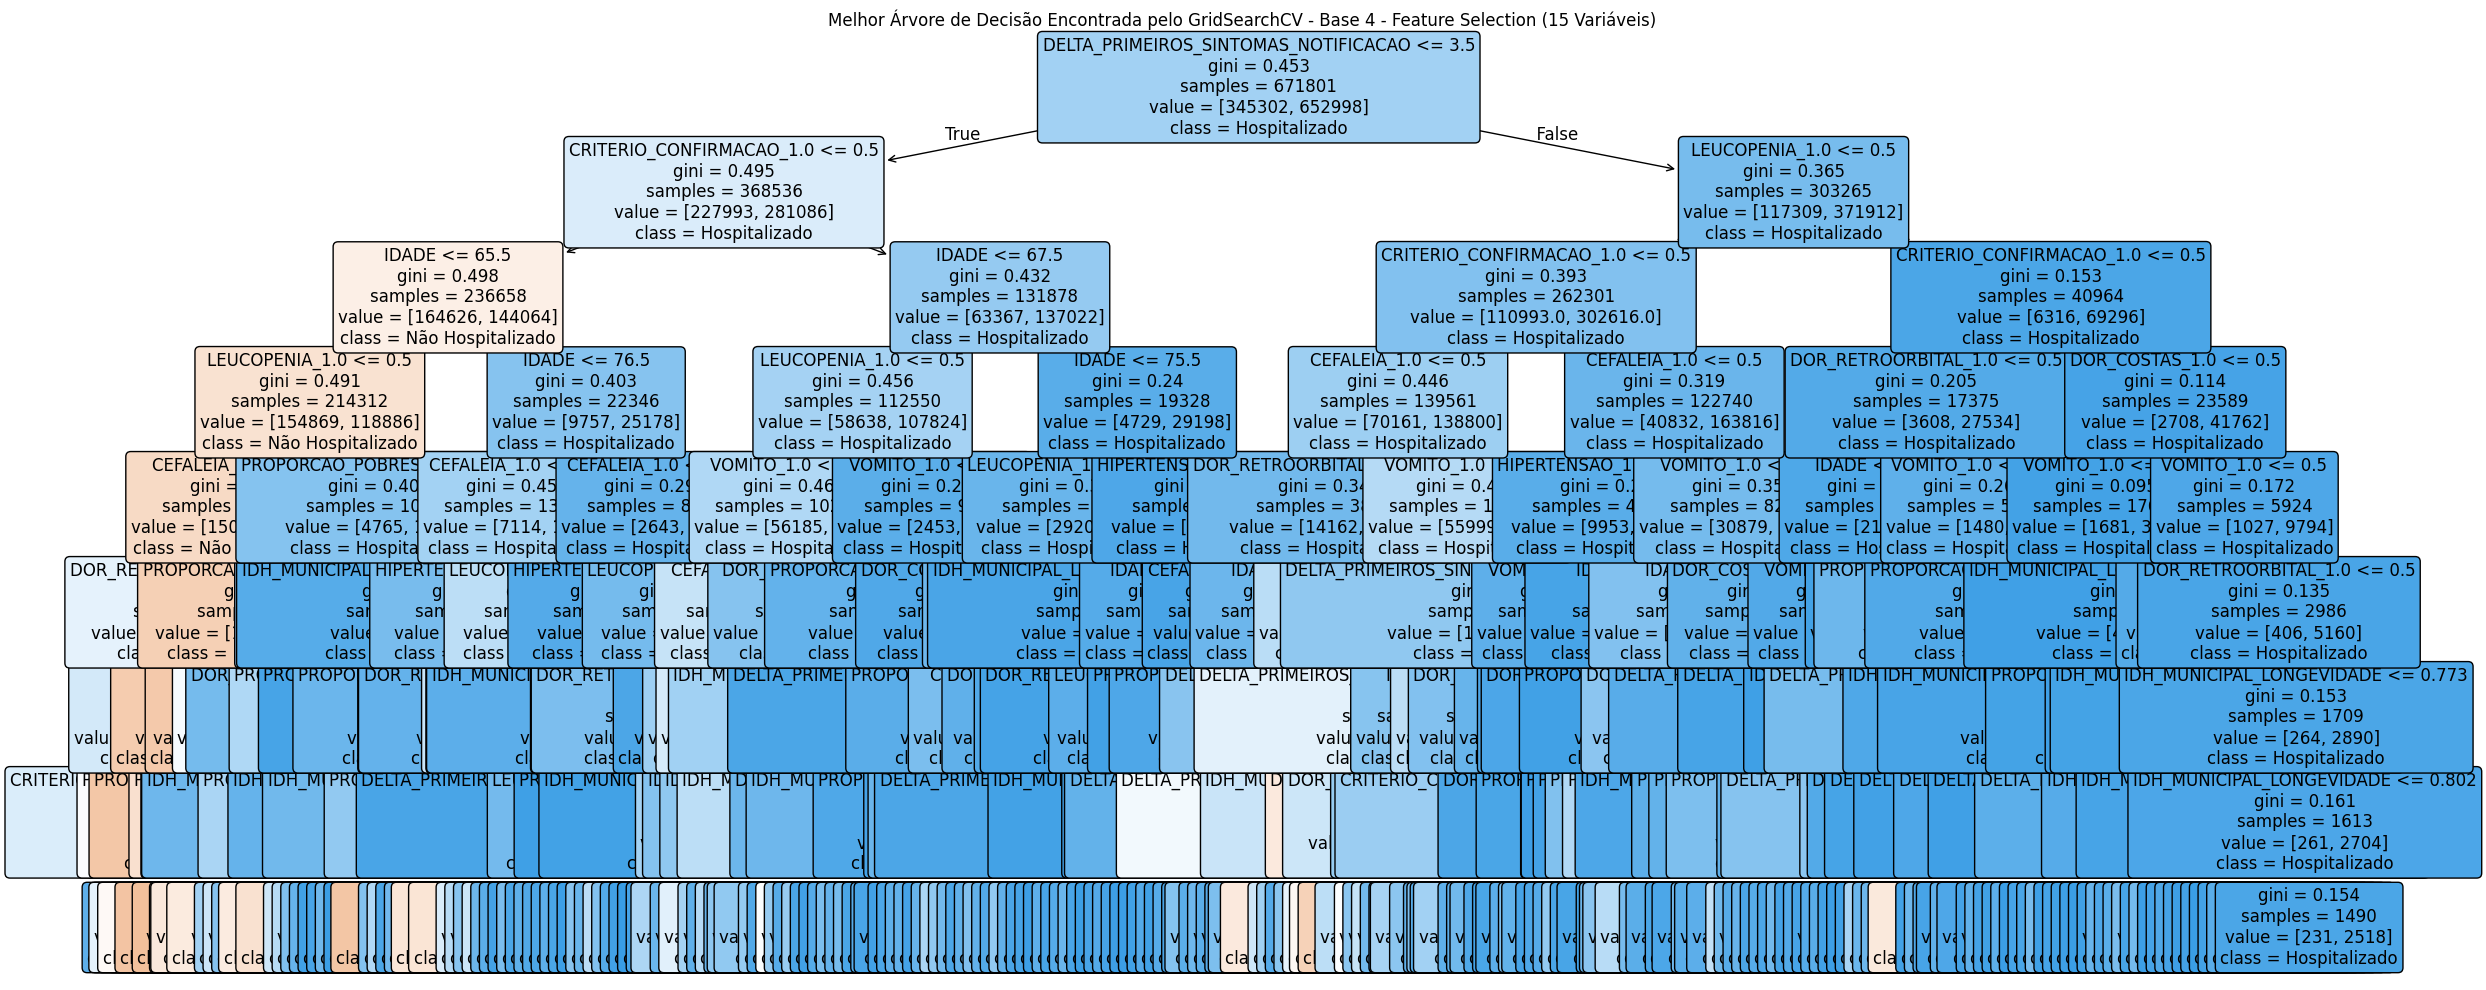

In [ ]:
num_cols= 15
top_features = df_ranking.head(num_cols).index.tolist()
df_4 = df_1[top_features + ["ANO", "HOSPITALIZACAO"]]

run_dt_pipeline(df_4, f"Base 4 - Feature Selection ({num_cols} Variáveis)", encode=False)

df_4.to_csv("dados/BASE_v3.csv", index=False)